In [2]:
# from common import *
from my import *

import os
import random
from pathlib import Path
from IPython.display import display, HTML

from tqdm import tqdm
from itertools import product
import joblib
from joblib import Parallel, delayed, parallel_backend

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

import time
import datetime
from datetime import datetime
from timeit import default_timer as timer
from dateutil.relativedelta import relativedelta

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
%config InlineBackend.figure_format='retina'

# set random seed for reproducibility
def set_seeds(seed=777):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

SEED = 777
set_seeds(SEED)
print(f'Random seed set to: {SEED}')

# checking
set_seeds(SEED)
print(np.random.rand(3))
set_seeds(SEED)
print(np.random.rand(3))

Random seed set to: 777
[0.15266373 0.30235661 0.06203641]
[0.15266373 0.30235661 0.06203641]


# Load Data

In [3]:
# read datasets and combine

# set base path
# use 'Path' to work from the 'data' folder in the current working directory
base_path = Path.cwd() / 'data'

# list of folders by dataset type
dataset_folders = [
    'Sleep Disorders', 'Kidney Conditions - Urology', 'Medical Conditions', 
    'Mental Health - Depression Screener', 'Occupation', 'Oral Health', 
    'Pesticide Use', 'Physical Activity', 'Physical Activity - Youth', 
    'Prescription Medications', 'Preventive Aspirin Use', 'Reproductive Health', 
    'Smoking - Cigarette Use', 'Smoking - Household Smokers', 
    'Smoking - Recent Tobacco Use', 'Weight History'
]

# read all .xpt files in one folder and combine them
# find all .xpt files using glob and read with pd.read_sas
def read_and_concat_datasets(folder_path):
    # get all .xpt files in the folder
    xpt_files = list(folder_path.glob('*.xpt'))
    if not xpt_files:
        print(f'Warning: no .xpt files found in {folder_path}')
        return None
    # read each .xpt file and save in a list
    dfs = [pd.read_sas(file) for file in xpt_files]
    # combine them vertically
    combined_df = pd.concat(dfs, axis=0, ignore_index=True)
    print(f'combined shape for {folder_path.name}: {combined_df.shape}')
    return combined_df

# keep only common columns
def filter_common_columns(df_list):
    # if only one dataframe, return its columns
    if len(df_list) < 2:
        return df_list[0].columns
    # get common columns between datasets using set.intersection
    common_cols = set(df_list[0].columns)
    for df in df_list[1:]:
        common_cols = common_cols.intersection(df.columns)
    return common_cols

# save combined dataframes into a dictionary
dataframes = {}
for folder in dataset_folders:
    folder_path = base_path / folder
    if folder_path.exists():
        xpt_files = list(folder_path.glob('*.xpt'))
        # process only if there are two or more files
        if len(xpt_files) > 1:
            combined_df = read_and_concat_datasets(folder_path)
            if combined_df is not None:
                dfs = [pd.read_sas(file) for file in xpt_files]
                common_cols = filter_common_columns(dfs)
                dataframes[folder] = combined_df[list(common_cols)]
        else:
            print(f'only one dataset exists at {folder_path}.')
    else:
        print(f'the folder path {folder_path} not exists!')

print('total datasets:', len(dataframes.keys()))
print(list(dataframes.keys()))

combined shape for Sleep Disorders: (18696, 11)
combined shape for Kidney Conditions - Urology: (17041, 17)
combined shape for Medical Conditions: (26730, 63)
combined shape for Mental Health - Depression Screener: (15302, 11)
combined shape for Occupation: (18696, 8)
combined shape for Oral Health: (26730, 43)
combined shape for Pesticide Use: (20266, 3)
combined shape for Physical Activity: (17846, 23)
combined shape for Physical Activity - Youth: (7922, 3)
combined shape for Prescription Medications: (44895, 15)
combined shape for Preventive Aspirin Use: (12158, 4)
combined shape for Reproductive Health: (9231, 32)
combined shape for Smoking - Cigarette Use: (20152, 16)
combined shape for Smoking - Household Smokers: (27493, 3)
combined shape for Smoking - Recent Tobacco Use: (17608, 26)
combined shape for Weight History: (18696, 35)
total datasets: 16
['Sleep Disorders', 'Kidney Conditions - Urology', 'Medical Conditions', 'Mental Health - Depression Screener', 'Occupation', 'Oral 

# Rename Features

In [4]:
# variable name mapping
variable_mappings = {
    'Sleep Disorders': {
        'SEQN': 'respondent_id',
        'SLQ300': 'sleep_time_weekdays_usual',
        'SLQ310': 'wake_time_weekdays_usual',
        'SLD012': 'sleep_hours_weekdays',
        'SLQ320': 'sleep_time_weekends_usual',
        'SLQ330': 'wake_time_weekends_usual',
        'SLD013': 'sleep_hours_weekends'
    },
    'Kidney Conditions - Urology': {
        'SEQN': 'respondent_id',
        'KIQ022': 'ever_told_weak_kidneys',
        'KIQ025': 'dialysis_last_12_months',
        'KIQ005': 'urinary_leakage_frequency',
        'KIQ010': 'urine_loss_amount',
        'KIQ042': 'leak_during_physical_activity',
        'KIQ044': 'urinate_before_reaching_toilet',
        'KIQ048A': 'check_item_kidney', # used for survey flow control; 'CHECK ITEM' is used to skip or go to next question based on conditions; can be removed when analyzing
        'KIQ052': 'daily_activities_affected',
        'KIQ481': 'nighttime_urination_frequency'
    },
    'Medical Conditions': {
        'SEQN': 'respondent_id',
        'MCQ010': 'ever_told_asthma',
        'MCQ035': 'still_have_asthma',
        'MCQ040': 'asthma_attack_last_year',
        'MCQ050': 'emergency_visit_asthma_last_year',
        'AGQ030': 'hay_fever_last_year',
        'MCQ053': 'treatment_anemia_last_3_months',
        'MCQ145': 'check_item_medical_1',
        'MCQ149': 'menstrual_periods_started',
        'MCQ157': 'check_item_medical_2',
        'MCQ160A': 'ever_told_arthritis',
        'MCQ160B': 'ever_told_heart_failure',
        'MCQ160C': 'ever_told_coronary_disease',
        'MCQ160D': 'ever_told_angina',
        'MCQ160E': 'ever_told_heart_attack',
        'MCQ160F': 'ever_told_stroke',
        'MCQ160L': 'ever_told_liver_condition',
        'MCQ160M': 'ever_told_thyroid_problem',
        'MCQ160P': 'ever_told_copd',
        'MCQ170L': 'still_have_liver_condition',
        'MCQ170M': 'still_have_thyroid_problem',
        'MCQ195': 'arthritis_type',
        'MCQ220': 'ever_told_cancer',
        'MCQ230A': 'first_cancer_type',
        'MCQ230B': 'second_cancer_type',
        'MCQ230C': 'third_cancer_type',
        'MCQ230D': 'more_than_3_cancers',
        'MCQ500': 'ever_told_liver_condition_any',
        'MCQ510A': 'liver_condition_fatty',
        'MCQ510B': 'liver_condition_fibrosis',
        'MCQ510C': 'liver_condition_cirrhosis',
        'MCQ510D': 'liver_condition_viral_hepatitis',
        'MCQ510E': 'liver_condition_autoimmune',
        'MCQ510F': 'liver_condition_other',
        'MCQ515': 'check_item_medical_3',
        'MCQ550': 'ever_told_gallstones',
        'MCQ560': 'had_gallbladder_surgery',
        'OSQ230': 'metal_objects_in_body'
    },
    'Mental Health - Depression Screener': {
        'SEQN': 'respondent_id',
        'DPQ010': 'little_interest_last_2_weeks',
        'DPQ020': 'feeling_down_last_2_weeks',
        'DPQ030': 'trouble_sleeping_last_2_weeks',
        'DPQ040': 'feeling_tired_last_2_weeks',
        'DPQ050': 'poor_appetite_or_overeating_last_2_weeks',
        'DPQ060': 'feeling_bad_about_self_last_2_weeks',
        'DPQ070': 'trouble_concentrating_last_2_weeks',
        'DPQ080': 'moving_speaking_slow_or_fast_last_2_weeks',
        'DPQ090': 'thought_better_off_dead_last_2_weeks',
        'DPQ100': 'difficulty_from_problems_last_2_weeks'
    },
    'Occupation': {
        'SEQN': 'respondent_id',
        'OCD150': 'work_type_last_week',
        'OCQ180': 'hours_worked_last_week',
        'OCQ200': 'check_item_occupation',
        'OCQ210': 'usually_work_35_plus_hours',
        'OCQ215': 'days_worked_per_week_usual',
        'OCQ383': 'reason_not_worked_last_week'
    },
    'Oral Health': {
        'SEQN': 'respondent_id',
        'OHQ845': 'teeth_gums_health_rating',
        'OHQ620': 'mouth_ache_frequency_last_year',
        'OHQ630': 'felt_bad_due_to_mouth_last_year',
        'OHQ640': 'job_difficulty_due_to_mouth_last_year',
        'OHQ660': 'avoided_food_due_to_mouth_last_year',
        'OHQ670': 'couldnt_eat_due_to_mouth_last_year',
        'OHQ680': 'embarrassed_due_to_mouth_last_year'
    },
    'Pesticide Use': {
        'SEQN': 'respondent_id',
        'PUQ100': 'used_insect_control_last_7_days',
        'PUQ110': 'used_weed_control_last_7_days'
    },
    'Physical Activity': {
        'SEQN': 'respondent_id',
        'PAD790Q': 'moderate_ltpa_frequency',
        'PAD790U': 'moderate_ltpa_unit',
        'PAD800': 'minutes_moderate_ltpa',
        'PAD810Q': 'vigorous_ltpa_frequency',
        'PAD810U': 'vigorous_ltpa_unit',
        'PAD820': 'minutes_vigorous_ltpa',
        'PAD680': 'minutes_sedentary_activity'
    },
    'Physical Activity - Youth': {
        'SEQN': 'respondent_id',
        'PAQ706': 'days_active_60min',
        'PAQ711': 'hours_tv_videos_per_day'
    },
    'Prescription Medications': {
        'SEQN': 'respondent_id',
        'RXQ033': 'taken_prescription_last_30_days',
        'RXQ050': 'num_prescription_meds'
    },
    'Preventive Aspirin Use': {
        'SEQN': 'respondent_id',
        'RXQ510': 'doctor_advised_aspirin',
        'RXQ515': 'followed_aspirin_advice',
        'RXQ520': 'taking_aspirin_on_own'
    },
    'Reproductive Health': {
        'SEQN': 'respondent_id',
        'RHQ010': 'age_first_period',
        'RHQ031': 'regular_periods_last_12_months',
        'RHD043': 'reason_no_regular_periods',
        'RHQ060': 'age_last_period',
        'RHQ078': 'treated_pelvic_infection_ever',
        'RHQ131': 'ever_been_pregnant',
        'RHD143': 'pregnant_now',
        'RHD167': 'total_deliveries',
        'RHQ200': 'breastfeeding_now',
        'RHD280': 'had_hysterectomy',
        'RHQ305': 'both_ovaries_removed',
        'RHQ332': 'age_both_ovaries_removed'
    },
    'Smoking - Cigarette Use': {
        'SEQN': 'respondent_id',
        'SMQ020': 'smoked_100_cigs_lifetime',
        'SMQ040': 'smoke_cigs_now',
        'SMD641': 'days_smoked_cigs_last_30_days',
        'SMD650': 'avg_cigs_per_day_last_30_days',
        'SMD100MN': 'cig_menthol_indicator',
        'SMQ621': 'cigs_smoked_lifetime',
        'SMD630': 'age_first_cig',
        'SMAQUEX2': 'questionnaire_mode_flag'
    },
    'Smoking - Household Smokers': {
        'SEQN': 'respondent_id',
        'SMD460': 'num_smokers_in_house',
        'SMD470': 'num_smokers_inside_home'
    },
    'Smoking - Recent Tobacco Use': {
        'SEQN': 'respondent_id',
        'SMQ681': 'smoked_tobacco_last_5_days',
        'SMQ690A': 'used_cigs_last_5_days',
        'SMQ710': 'days_smoked_cigs_last_5_days',
        'SMQ720': 'cigs_per_day_last_5_days',
        'SMQ725': 'time_last_cigarette',
        'SMQ690B': 'used_pipes_last_5_days',
        'SMQ740': 'days_smoked_pipes_last_5_days',
        'SMQ690C': 'used_cigars_last_5_days',
        'SMQ770': 'days_smoked_cigars_last_5_days',
        'SMQ690D': 'used_chewing_tobacco_last_5_days',
        'SMQ690E': 'used_snuff_last_5_days',
        'SMQ690F': 'used_nicotine_patch_gum_last_5_days',
        'SMQ690G': 'used_hookah_last_5_days',
        'SMQ690K': 'used_other_smokeless_last_5_days',
        'SMQ845': 'days_smoked_hookah_last_5_days',
        'SMQ846': 'used_ecigs_last_5_days',
        'SMQ849': 'days_used_ecigs_last_5_days',
        'SMQ851': 'used_smokeless_tobacco_last_5_days',
        'SMQ863': 'used_nicotine_replacement_last_5_days',
        'SMDANY': 'used_any_tobacco_last_5_days'
    },
    'Weight History': {
        'SEQN': 'respondent_id',
        'WHD010': 'current_height_inches',
        'WHD020': 'current_weight_pounds',
        'WHD050': 'weight_last_1_year_pounds',
        'WHQ070': 'tried_lose_weight_last_year'
    }
}

# rename columns using a mapping
def rename_columns(df, mapping):
    return df.rename(columns=mapping)

# apply new names to each dataset
for idx, (folder, df) in enumerate(dataframes.items()):
    if folder in variable_mappings:
        dataframes[folder] = rename_columns(df, variable_mappings[folder])
        print(f'{idx+1}. renamed columns for {folder} {df.shape}: {dataframes[folder].columns.tolist()}')
    else:
        print(f'no mapping for {folder} {df.shape}, using original names')

1. renamed columns for Sleep Disorders (18696, 7): ['sleep_time_weekends_usual', 'wake_time_weekdays_usual', 'respondent_id', 'wake_time_weekends_usual', 'sleep_hours_weekdays', 'sleep_time_weekdays_usual', 'sleep_hours_weekends']
2. renamed columns for Kidney Conditions - Urology (17041, 8): ['dialysis_last_12_months', 'daily_activities_affected', 'ever_told_weak_kidneys', 'leak_during_physical_activity', 'urine_loss_amount', 'respondent_id', 'urinary_leakage_frequency', 'urinate_before_reaching_toilet']
3. renamed columns for Medical Conditions (26730, 35): ['menstrual_periods_started', 'still_have_thyroid_problem', 'ever_told_stroke', 'third_cancer_type', 'treatment_anemia_last_3_months', 'ever_told_thyroid_problem', 'liver_condition_cirrhosis', 'ever_told_gallstones', 'ever_told_coronary_disease', 'still_have_liver_condition', 'liver_condition_other', 'ever_told_liver_condition', 'liver_condition_autoimmune', 'asthma_attack_last_year', 'more_than_3_cancers', 'ever_told_angina', 'ev

In [6]:
len(dataframes)

16

In [9]:
dataframes.keys()

dict_keys(['Sleep Disorders', 'Kidney Conditions - Urology', 'Medical Conditions', 'Mental Health - Depression Screener', 'Occupation', 'Oral Health', 'Pesticide Use', 'Physical Activity', 'Physical Activity - Youth', 'Prescription Medications', 'Preventive Aspirin Use', 'Reproductive Health', 'Smoking - Cigarette Use', 'Smoking - Household Smokers', 'Smoking - Recent Tobacco Use', 'Weight History'])

In [10]:
dataframes['Sleep Disorders']['sleep_hours_weekdays'].value_counts()

sleep_hours_weekdays
8.0     3598
7.0     2870
9.0     2155
7.5     1848
8.5     1496
6.0     1410
6.5     1048
10.0     871
5.0      648
9.5      537
11.0     394
5.5      394
4.0      317
10.5     182
4.5      148
12.0     129
3.0      110
2.0       79
3.5       66
14.0      65
13.0      57
11.5      48
12.5      15
13.5       8
Name: count, dtype: int64

# Data Cleaning - Survey

## Kidney Conditions - Urology

In [23]:
df_kidney = dataframes['Kidney Conditions - Urology'].copy()
print('original columns in df_kidney:', df_kidney.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_kidney.columns:
    df_kidney['respondent_id'] = df_kidney['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# remove check item column if it exists
df_kidney.drop(columns=['check_item_kidney'], inplace=True, errors='ignore')

# change special values (refused, don't know, missing) to NA
for col in df_kidney.columns:
    if col != 'respondent_id':
        df_kidney[col] = df_kidney[col].replace([7, 9, 77, 99, 777, 999, 7777, 9999], pd.NA)

# clean yes/no variables (1 = yes, 2 = no → 1/0)
binary_vars = [
    'ever_told_weak_kidneys',
    'dialysis_last_12_months',
    'leak_during_physical_activity',
    'urinate_before_reaching_toilet'
]

for var in binary_vars:
    if var in df_kidney.columns:
        df_kidney[var] = df_kidney[var].map({1: 1, 2: 0}).astype('Int64')
    else:
        print(f'warning: binary variable '{var}' not found in dataframe')

# turn leakage frequency into words and new column
if 'urinary_leakage_frequency' in df_kidney.columns:
    leakage_map = {
        1: 'never',
        2: '<1/month',
        3: 'few/month',
        4: 'few/week',
        5: 'daily'
    }
    df_kidney['urinary_leakage_freq_category'] = (
        df_kidney['urinary_leakage_frequency']
        .map(leakage_map)
        .astype('category')
    )
    
    # make new column for frequent leakage (at least weekly)
    df_kidney['frequent_urinary_leakage'] = (
        df_kidney['urinary_leakage_frequency'] >= 4
    ).astype('Int64')

# turn urine loss amount into words
if 'urine_loss_amount' in df_kidney.columns:
    loss_map = {
        1: 'drops',
        2: 'small_splashes',
        3: 'more'
    }
    df_kidney['urine_loss_category'] = (
        df_kidney['urine_loss_amount']
        .map(loss_map)
        .astype('category')
    )

# turn impact on daily life into words
if 'daily_activities_affected' in df_kidney.columns:
    impact_map = {
        1: 'not_at_all',
        2: 'only_a_little',
        3: 'somewhat',
        4: 'very_much',
        5: 'greatly'
    }
    df_kidney['daily_impact_category'] = (
        df_kidney['daily_activities_affected']
        .map(impact_map)
        .astype('category')
    )
    
    # new column: big impact if value is 3 or more
    df_kidney['significant_daily_impact'] = (
        df_kidney['daily_activities_affected'] >= 3
    ).astype('Int64')

# change nighttime urination number to words
if 'nighttime_urination_frequency' in df_kidney.columns:
    nocturia_map = {
        0: 'none',
        1: 'once',
        2: 'twice',
        3: 'three_times',
        4: 'four_times',
        5: 'five_or_more'
    }
    df_kidney['nocturia_category'] = (
        df_kidney['nighttime_urination_frequency']
        .map(nocturia_map)
        .astype('category')
    )
    
    # new column: important if 2 or more times per night
    df_kidney['clinically_significant_nocturia'] = (
        df_kidney['nighttime_urination_frequency'] >= 2
    ).astype('Int64')

# make a new column for any urinary incontinence
if all(col in df_kidney.columns for col in ['leak_during_physical_activity', 'urinate_before_reaching_toilet']):
    leak_physical = df_kidney['leak_during_physical_activity'].fillna(0)
    leak_urge = df_kidney['urinate_before_reaching_toilet'].fillna(0)
    
    df_kidney['any_urinary_incontinence'] = (
        (leak_physical == 1) | (leak_urge == 1)
    ).astype('Int64')

# make a kidney disease level column
if all(col in df_kidney.columns for col in ['ever_told_weak_kidneys', 'dialysis_last_12_months']):
    df_kidney['kidney_disease_status'] = pd.NA
    
    mask_dialysis = df_kidney['dialysis_last_12_months'] == 1
    mask_kidney_disease = (df_kidney['ever_told_weak_kidneys'] == 1) & ~mask_dialysis
    mask_no_disease = (df_kidney['ever_told_weak_kidneys'] == 0) & ~mask_dialysis
    
    df_kidney.loc[mask_dialysis, 'kidney_disease_status'] = 'dialysis'
    df_kidney.loc[mask_kidney_disease, 'kidney_disease_status'] = 'kidney_disease'
    df_kidney.loc[mask_no_disease, 'kidney_disease_status'] = 'no_kidney_disease'
    
    df_kidney['kidney_disease_status'] = df_kidney['kidney_disease_status'].astype('category')

# save cleaned data back to dictionary
dataframes['Kidney Conditions - Urology'] = df_kidney
df_kidney.head(2)

original columns in df_kidney: ['dialysis_last_12_months', 'daily_activities_affected', 'ever_told_weak_kidneys', 'leak_during_physical_activity', 'urine_loss_amount', 'respondent_id', 'urinary_leakage_frequency', 'urinate_before_reaching_toilet', 'urinary_leakage_freq_category', 'frequent_urinary_leakage', 'urine_loss_category', 'daily_impact_category', 'significant_daily_impact', 'any_urinary_incontinence', 'kidney_disease_status']


,dialysis_last_12_months,daily_activities_affected,ever_told_weak_kidneys,leak_during_physical_activity,urine_loss_amount,respondent_id,urinary_leakage_frequency,urinate_before_reaching_toilet,urinary_leakage_freq_category,frequent_urinary_leakage,urine_loss_category,daily_impact_category,significant_daily_impact,any_urinary_incontinence,kidney_disease_status
0,<NA>,NaN,<NA>,<NA>,NaN,109266,1.0,<NA>,never,0,NaN,NaN,0,0,NaN
1,<NA>,NaN,<NA>,<NA>,NaN,109267,NaN,<NA>,NaN,0,NaN,NaN,0,0,NaN


In [34]:
print(f'{df_kidney['ever_told_weak_kidneys'].mean()*100:.1f}%') # percentage with weak/failing kidneys
print(f'{df_kidney['dialysis_last_12_months'].mean()*100:.1f}%') # percentage receiving dialysis
# print(f'{df_kidney['clinically_significant_nocturia'].mean()*100:.1f}%') # Percentage with clinically significant nocturia (≥2 times/night)
print(f'{df_kidney['any_urinary_incontinence'].mean()*100:.1f}%') # percentage with any urinary incontinence

100.0%
100.0%
33.7%


## Medical Conditions

In [21]:
df_medical = dataframes['Medical Conditions'].copy()
print('Original columns in df_medical:', df_medical.columns.tolist())

# remove check items if they exist
df_medical.drop(columns=['check_item_medical_1', 'check_item_medical_2', 'check_item_medical_3'], inplace=True, errors='ignore')

# change respondent_id to string if it exists
if 'respondent_id' in df_medical.columns:
    df_medical['respondent_id'] = df_medical['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# change refused, don't know, missing to NA
# missing codes: 7, 9, 77, 99, 777, 999, 7777, 9999
for col in df_medical.columns:
    df_medical[col] = df_medical[col].replace([7, 9, 77, 99, 777, 999, 7777, 9999], pd.NA)

# handle binary variables (1/2 to 1/0)
binary_vars = [
    'ever_told_asthma', 'still_have_asthma', 'asthma_attack_last_year',
    'emergency_visit_asthma_last_year', 'hay_fever_last_year',
    'treatment_anemia_last_3_months', 'menstrual_periods_started',
    'ever_told_arthritis', 'ever_told_heart_failure', 'ever_told_coronary_disease',
    'ever_told_angina', 'ever_told_heart_attack', 'ever_told_stroke',
    'ever_told_thyroid_problem', 'still_have_thyroid_problem',
    'ever_told_copd', 'ever_told_liver_condition', 'still_have_liver_condition',
    'ever_told_liver_condition_any', 'ever_told_gallstones',
    'had_gallbladder_surgery', 'ever_told_cancer', 'metal_objects_in_body'
]
for var in binary_vars:
    if var in df_medical.columns:
        df_medical[var] = df_medical[var].map({1: 1, 2: 0}).astype('Int64')
    else:
        print(f'Warning: binary variable '{var}' not found in dataframe')

# handle categorical variables with multiple options
# arthritis type
if 'arthritis_type' in df_medical.columns:
    df_medical['arthritis_type'] = df_medical['arthritis_type'].replace({
        1: 'osteoarthritis',
        2: 'rheumatoid',
        3: 'psoriatic',
        4: 'other',
        7: pd.NA, # 'Refused'
        9: pd.NA  # 'Don't know'
    }).astype('category')

# liver conditions (multiple can be selected)
liver_conditions = [
    'liver_condition_fatty', 'liver_condition_fibrosis',
    'liver_condition_cirrhosis', 'liver_condition_viral_hepatitis',
    'liver_condition_autoimmune', 'liver_condition_other'
]

for var in liver_conditions:
    if var in df_medical.columns:
        df_medical[var] = df_medical[var].map({1: 1, 2: 0, 77: pd.NA, 99: pd.NA}).astype('Int64')

# cancer types (create indicator variables for common cancers)
if 'first_cancer_type' in df_medical.columns:
    common_cancers = {
        'cancer_breast': 14,
        'cancer_prostate': 30,
        'cancer_skin_non_melanoma': 32,
        'cancer_skin_unknown': 33,
        'cancer_colon': 16,
        'cancer_lung': 23,
        'cancer_thyroid': 37,
        'cancer_uterus': 38,
        'cancer_cervix': 15,
        'cancer_melanoma': 25
    }
    
    for name, code in common_cancers.items():
        df_medical[name] = ((df_medical['first_cancer_type'] == code) | 
                            (df_medical['second_cancer_type'] == code) |
                            (df_medical['third_cancer_type'] == code)).astype('Int64')

# create composite variables
# asthma status (combines ever told and still has)
if all(col in df_medical.columns for col in ['ever_told_asthma', 'still_have_asthma']):
    df_medical['current_asthma'] = df_medical['ever_told_asthma'] & df_medical['still_have_asthma']
    df_medical['current_asthma'] = df_medical['current_asthma'].astype('Int64')

# cardiovascular disease composite
if all(col in df_medical.columns for col in ['ever_told_heart_failure', 'ever_told_coronary_disease', 'ever_told_angina', 'ever_told_heart_attack']):
    df_medical['cardiovascular_disease'] = (
        df_medical['ever_told_heart_failure'] | 
        df_medical['ever_told_coronary_disease'] | 
        df_medical['ever_told_angina'] | 
        df_medical['ever_told_heart_attack']
    ).astype('Int64')

# chronic condition count
chronic_conditions = [
    'ever_told_asthma', 'ever_told_arthritis', 'ever_told_heart_failure',
    'ever_told_coronary_disease', 'ever_told_angina', 'ever_told_heart_attack',
    'ever_told_stroke', 'ever_told_thyroid_problem', 'ever_told_copd',
    'ever_told_liver_condition', 'ever_told_gallstones', 'ever_told_cancer'
]

if all(col in df_medical.columns for col in chronic_conditions):
    df_medical['chronic_condition_count'] = df_medical[chronic_conditions].sum(axis=1)

# save cleaned dataframe
dataframes['Medical Conditions'] = df_medical

Original columns in df_medical: ['menstrual_periods_started', 'still_have_thyroid_problem', 'ever_told_stroke', 'third_cancer_type', 'treatment_anemia_last_3_months', 'ever_told_thyroid_problem', 'liver_condition_cirrhosis', 'ever_told_gallstones', 'ever_told_coronary_disease', 'still_have_liver_condition', 'liver_condition_other', 'ever_told_liver_condition', 'liver_condition_autoimmune', 'asthma_attack_last_year', 'more_than_3_cancers', 'ever_told_angina', 'ever_told_heart_failure', 'first_cancer_type', 'second_cancer_type', 'ever_told_heart_attack', 'arthritis_type', 'ever_told_copd', 'hay_fever_last_year', 'ever_told_asthma', 'metal_objects_in_body', 'respondent_id', 'liver_condition_fibrosis', 'ever_told_arthritis', 'emergency_visit_asthma_last_year', 'still_have_asthma', 'ever_told_liver_condition_any', 'liver_condition_viral_hepatitis', 'ever_told_cancer', 'liver_condition_fatty', 'had_gallbladder_surgery', 'cancer_breast', 'cancer_prostate', 'cancer_skin_non_melanoma', 'cancer_

In [22]:
# handle special cases
# menstrual periods started is only for females 8-11, so missing is expected for others
if 'menstrual_periods_started' in df_medical.columns:
    print(df_medical['menstrual_periods_started'].value_counts(dropna=False))

menstrual_periods_started
<NA>    26572
1         158
Name: count, dtype: Int64


In [35]:
# average number of chronic conditions
print(f'{df_medical['chronic_condition_count'].mean():.2f}')
# percentage with each condition
for cond in chronic_conditions:
    if cond in df_medical.columns:
        print(f'- {cond}: {df_medical[cond].mean()*100:.1f}%')

0.81
- ever_told_asthma: 100.0%
- ever_told_arthritis: 100.0%
- ever_told_heart_failure: 100.0%
- ever_told_coronary_disease: 100.0%
- ever_told_angina: 100.0%
- ever_told_heart_attack: 100.0%
- ever_told_stroke: 100.0%
- ever_told_thyroid_problem: 100.0%
- ever_told_copd: 100.0%
- ever_told_liver_condition: 100.0%
- ever_told_gallstones: 100.0%
- ever_told_cancer: 100.0%


## Mental Helath

In [24]:
df_depression = dataframes['Mental Health - Depression Screener'].copy()
print('Original columns in df_depression:', df_depression.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_depression.columns:
    df_depression['respondent_id'] = df_depression['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7, 9)
depression_items = [
    'little_interest_last_2_weeks', 'feeling_down_last_2_weeks',
    'trouble_sleeping_last_2_weeks', 'feeling_tired_last_2_weeks',
    'poor_appetite_or_overeating_last_2_weeks', 'feeling_bad_about_self_last_2_weeks',
    'trouble_concentrating_last_2_weeks', 'moving_speaking_slow_or_fast_last_2_weeks',
    'thought_better_off_dead_last_2_weeks', 'difficulty_from_problems_last_2_weeks'
]

for item in depression_items:
    if item in df_depression.columns:
        # convert to numeric first to handle any string representations
        df_depression[item] = pd.to_numeric(df_depression[item], errors='coerce')
        # then replace special codes with NA
        df_depression[item] = df_depression[item].replace([7, 9], pd.NA)
    else:
        print(f'Warning: depression item '{item}' not found in dataframe')

# create PHQ-9 total score (sum of items DPQ010-DPQ090)
phq9_items = [
    'little_interest_last_2_weeks', 'feeling_down_last_2_weeks',
    'trouble_sleeping_last_2_weeks', 'feeling_tired_last_2_weeks',
    'poor_appetite_or_overeating_last_2_weeks', 'feeling_bad_about_self_last_2_weeks',
    'trouble_concentrating_last_2_weeks', 'moving_speaking_slow_or_fast_last_2_weeks',
    'thought_better_off_dead_last_2_weeks'
]

if all(item in df_depression.columns for item in phq9_items):
    # only calculate if at least 6 items are answered (PHQ-9 scoring rule)
    df_depression['phq9_missing_count'] = df_depression[phq9_items].isnull().sum(axis=1)
    df_depression['phq9_total'] = df_depression[phq9_items].sum(axis=1, min_count=6)
    df_depression['phq9_total'] = df_depression['phq9_total'].where(
        df_depression['phq9_missing_count'] <= 3, pd.NA
    )
    df_depression.drop(columns=['phq9_missing_count'], inplace=True)
    
    # create depression severity categories (only for non-NA values)
    mask = df_depression['phq9_total'].notna()
    depression_severity = pd.Series(pd.NA, index=df_depression.index, dtype='object')
    
    depression_severity[mask] = pd.cut(
        df_depression.loc[mask, 'phq9_total'],
        bins=[-1, 4, 9, 14, 19, 27],
        labels=['none', 'mild', 'moderate', 'moderately_severe', 'severe'],
        right=True
    )
    df_depression['depression_severity'] = depression_severity.astype('category')
    
    # create binary depression indicator (>=10 is commonly used cutoff)
    df_depression['depression_binary'] = (df_depression['phq9_total'] >= 10).astype('Int64')

# create individual symptom flags (for specific sleep-related analysis)
if 'trouble_sleeping_last_2_weeks' in df_depression.columns:
    df_depression['sleep_problems_flag'] = (df_depression['trouble_sleeping_last_2_weeks'] >= 2).astype('Int64')

if 'feeling_tired_last_2_weeks' in df_depression.columns:
    df_depression['fatigue_flag'] = (df_depression['feeling_tired_last_2_weeks'] >= 2).astype('Int64')

# handle functional impairment (DPQ100)
# check if functional problem column exists
if 'difficulty_from_problems_last_2_weeks' in df_depression.columns:
    # change to number
    df_depression['difficulty_from_problems_last_2_weeks'] = pd.to_numeric(
        df_depression['difficulty_from_problems_last_2_weeks'], errors='coerce'
    )
    # change special codes to NA
    df_depression['difficulty_from_problems_last_2_weeks'] = df_depression['difficulty_from_problems_last_2_weeks'].replace([7, 9], pd.NA)
    
    # check if there are any decimal values before changing to integer
    if (df_depression['difficulty_from_problems_last_2_weeks'].dropna() % 1 != 0).any():
        print('Warning: Non-integer values found in difficulty_from_problems_last_2_weeks')
    
    # change to float, round, then to Int64
    df_depression['functional_impairment'] = (
        df_depression['difficulty_from_problems_last_2_weeks']
        .astype(float)
        .round(0)
        .astype('Int64')
    )
    # make a new column that shows if the problem is big
    df_depression['significant_impairment'] = (df_depression['functional_impairment'] >= 2).astype('Int64')

# make sleep problem score using sleep and tired questions
if all(item in df_depression.columns for item in ['trouble_sleeping_last_2_weeks', 'feeling_tired_last_2_weeks']):
    # change to number
    sleep_trouble = pd.to_numeric(df_depression['trouble_sleeping_last_2_weeks'], errors='coerce')
    fatigue = pd.to_numeric(df_depression['feeling_tired_last_2_weeks'], errors='coerce')
    
    # change missing to 0 after converting
    sleep_trouble_filled = sleep_trouble.fillna(0).astype('int64')
    fatigue_filled = fatigue.fillna(0).astype('int64')
    
    # add sleep and tired scores
    df_depression['sleep_disturbance_score'] = sleep_trouble_filled + fatigue_filled

# save cleaned dataframe
dataframes['Mental Health - Depression Screener'] = df_depression

df_depression.head(2)

Original columns in df_depression: ['difficulty_from_problems_last_2_weeks', 'thought_better_off_dead_last_2_weeks', 'feeling_tired_last_2_weeks', 'little_interest_last_2_weeks', 'feeling_down_last_2_weeks', 'trouble_concentrating_last_2_weeks', 'trouble_sleeping_last_2_weeks', 'feeling_bad_about_self_last_2_weeks', 'moving_speaking_slow_or_fast_last_2_weeks', 'respondent_id', 'poor_appetite_or_overeating_last_2_weeks']


,difficulty_from_problems_last_2_weeks,thought_better_off_dead_last_2_weeks,feeling_tired_last_2_weeks,little_interest_last_2_weeks,feeling_down_last_2_weeks,trouble_concentrating_last_2_weeks,trouble_sleeping_last_2_weeks,feeling_bad_about_self_last_2_weeks,moving_speaking_slow_or_fast_last_2_weeks,respondent_id,poor_appetite_or_overeating_last_2_weeks,phq9_total,depression_severity,depression_binary,sleep_problems_flag,fatigue_flag,functional_impairment,significant_impairment,sleep_disturbance_score
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130378,NaN,<NA>,NaN,0,0,0,<NA>,<NA>,0
1,5.397605e-79,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,130379,0.0,1.0,none,0,0,0,0,0,1


In [25]:
print(df_depression.isnull().sum())
print(df_depression.dtypes)

difficulty_from_problems_last_2_weeks        5607
thought_better_off_dead_last_2_weeks         1505
feeling_tired_last_2_weeks                   1499
little_interest_last_2_weeks                 1506
feeling_down_last_2_weeks                    1495
trouble_concentrating_last_2_weeks           1498
trouble_sleeping_last_2_weeks                1495
feeling_bad_about_self_last_2_weeks          1502
moving_speaking_slow_or_fast_last_2_weeks    1509
respondent_id                                   0
poor_appetite_or_overeating_last_2_weeks     1493
phq9_total                                   1495
depression_severity                          1495
depression_binary                               0
sleep_problems_flag                             0
fatigue_flag                                    0
functional_impairment                        5607
significant_impairment                       5607
sleep_disturbance_score                         0
dtype: int64
difficulty_from_problems_last_2_weeks

```
PHQ-9 Score Ranges:
- 0-4: None
- 5-9: Mild
- 10-14: Moderate
- 15-19: Moderately severe
- 20-27: Severe
```

In [32]:
print(df_depression['depression_severity'].value_counts(normalize=True, dropna=False))
print(f'{df_depression['depression_binary'].mean()*100:.1f}%') # percentage with clinically significant depression (PHQ-9 >= 10)
print(f'{df_depression['sleep_problems_flag'].mean()*100:.1f}%') # percentage with sleep problems (≥more than half days)

depression_severity
none                 0.639982
mild                 0.164227
NaN                  0.097700
moderate             0.062933
moderately_severe    0.025029
severe               0.010129
Name: proportion, dtype: float64
9.8%
15.9%


In [27]:
dataframes['Mental Health - Depression Screener']['phq9_total'].value_counts()

phq9_total
0.0     4081
1.0     1845
2.0     1638
3.0     1272
4.0      943
5.0      725
6.0      599
7.0      455
8.0      421
9.0      313
10.0     288
11.0     239
12.0     184
13.0     130
14.0     122
15.0     104
16.0      80
18.0      77
17.0      74
19.0      48
20.0      42
21.0      32
22.0      27
23.0      25
24.0      15
0.0       10
25.0       8
26.0       5
0.0        3
0.0        1
27.0       1
Name: count, dtype: int64

## Occupation

In [29]:
df_occupation = dataframes['Occupation'].copy()
print('Original columns in df_occupation:', df_occupation.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_occupation.columns:
    df_occupation['respondent_id'] = df_occupation['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# remove check items if they exist
df_occupation.drop(columns=['check_item_occupation'], inplace=True, errors='ignore')

# handle missing/refused/don't know responses
# missing codes: 7, 9, 77, 99, 777, 999, 7777, 9999, 77777, 99999
for col in df_occupation.columns:
    if col != 'respondent_id':
        df_occupation[col] = df_occupation[col].replace([7, 9, 77, 99, 77777, 99999], pd.NA)

# clean specific occupation variables
# work type (OCD150)
if 'work_type_last_week' in df_occupation.columns:
    work_type_mapping = {
        1: 'working',
        2: 'has_job_not_working',
        3: 'looking_for_work',
        4: 'not_working'
    }
    df_occupation['work_type_last_week'] = df_occupation['work_type_last_week'].map(work_type_mapping).astype('category')

# hours worked last week (OCQ180)
if 'hours_worked_last_week' in df_occupation.columns:
    # handle special values (already converted to NA)
    # create a categorical version for analysis
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, float('inf')]
    labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']
    df_occupation['hours_worked_last_week_category'] = pd.cut(
        pd.to_numeric(df_occupation['hours_worked_last_week'], errors='coerce'),
        bins=bins,
        labels=labels,
        right=False
    ).astype('category')

# usually work 35+ hours (OCQ210)
if 'usually_work_35_plus_hours' in df_occupation.columns:
    df_occupation['usually_work_35_plus_hours'] = df_occupation['usually_work_35_plus_hours'].map({
        1: 1,  # Yes
        2: 0    # No
    }).astype('Int64')

# days usually worked per week (OCQ215)
if 'days_worked_per_week_usual' in df_occupation.columns:
    # create categorical version
    days_mapping = {
        1: '1 day',
        2: '2 days',
        3: '3 days',
        4: '4 days',
        5: '5 days',
        6: '6 days',
        7: '7 days'
    }
    df_occupation['days_worked_category'] = df_occupation['days_worked_per_week_usual'].map(days_mapping).astype('category')

# reason not working (OCQ383)
if 'reason_not_worked_last_week' in df_occupation.columns:
    reason_mapping = {
        1: 'caregiving',
        2: 'student',
        3: 'retired',
        4: 'disabled',
        5: 'unemployed',
        6: 'seasonal',
        7: 'other'
    }
    df_occupation['reason_not_working'] = df_occupation['reason_not_worked_last_week'].map(reason_mapping).astype('category')

# make new columns from other columns
if all(col in df_occupation.columns for col in ['hours_worked_last_week', 'usually_work_35_plus_hours']):
    # change values to numbers first
    hours_worked = pd.to_numeric(df_occupation['hours_worked_last_week'], errors='coerce')
    usually_35plus = pd.to_numeric(df_occupation['usually_work_35_plus_hours'], errors='coerce')
    
    # make conditions (also check missing values)
    condition1 = ((hours_worked >= 35) | (usually_35plus == 1)).fillna(False)
    condition2 = ((hours_worked < 35) & (hours_worked > 0)).fillna(False)
    condition3 = (hours_worked == 0).fillna(False)
    
    conditions = [condition1, condition2, condition3]
    choices = ['full_time', 'part_time', 'not_working']
    
    # choose value based on the condition
    df_occupation['work_intensity'] = np.select(conditions, choices, default=pd.NA)
    df_occupation['work_intensity'] = df_occupation['work_intensity'].astype('category')

# 8. Save cleaned dataframe
dataframes['Occupation'] = df_occupation
df_occupation.head(2)

Original columns in df_occupation: ['usually_work_35_plus_hours', 'hours_worked_last_week', 'respondent_id', 'work_type_last_week']


,usually_work_35_plus_hours,hours_worked_last_week,respondent_id,work_type_last_week,hours_worked_last_week_category,work_intensity
0,<NA>,40.0,109266,working,40-50,full_time
1,<NA>,40.0,109267,working,40-50,full_time


In [30]:
print(df_occupation.isnull().sum())
print(df_occupation.dtypes)

usually_work_35_plus_hours         15528
hours_worked_last_week              9164
respondent_id                          0
work_type_last_week                   22
hours_worked_last_week_category     9164
work_intensity                      8811
dtype: int64
usually_work_35_plus_hours            Int64
hours_worked_last_week               object
respondent_id                        object
work_type_last_week                category
hours_worked_last_week_category    category
work_intensity                     category
dtype: object


In [36]:
print(df_occupation['work_type_last_week'].value_counts(dropna=False))
print(df_occupation['hours_worked_last_week_category'].value_counts(dropna=False))
# print(df_occupation['reason_not_working'].value_counts(dropna=False))

work_type_last_week
working                9617
not_working            7752
looking_for_work        824
has_job_not_working     481
NaN                      22
Name: count, dtype: int64
hours_worked_last_week_category
NaN      9164
40-50    4265
30-40    1454
50-60    1093
20-30     950
10-20     623
60-70     561
0-10      279
70-80     171
80+       136
Name: count, dtype: int64


## Oral Health

In [38]:
df_oral = dataframes['Oral Health'].copy()
print('Original columns in df_oral:', df_oral.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_oral.columns:
    df_oral['respondent_id'] = df_oral['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7, 9)
oral_health_items = [
    'teeth_gums_health_rating',
    'mouth_ache_frequency_last_year',
    'felt_bad_due_to_mouth_last_year',
    'job_difficulty_due_to_mouth_last_year',
    'avoided_food_due_to_mouth_last_year',
    'couldnt_eat_due_to_mouth_last_year',
    'embarrassed_due_to_mouth_last_year'
]

for item in oral_health_items:
    if item in df_oral.columns:
        # convert to numeric first to handle any string representations
        df_oral[item] = pd.to_numeric(df_oral[item], errors='coerce')
        # then replace special codes with NA
        df_oral[item] = df_oral[item].replace([7, 9], pd.NA)
    else:
        print(f'Warning: oral health item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# teeth/gums health rating
if 'teeth_gums_health_rating' in df_oral.columns:
    health_rating_map = {
        1: 'excellent',
        2: 'very_good',
        3: 'good',
        4: 'fair',
        5: 'poor'
    }
    df_oral['oral_health_rating'] = (
        df_oral['teeth_gums_health_rating']
        .map(health_rating_map)
        .astype('category')
    )
    
    # create binary indicator for poor oral health
    df_oral['poor_oral_health'] = (
        df_oral['teeth_gums_health_rating'] >= 4
    ).astype('Int64')

# frequency variables (convert to ordinal scale)
frequency_vars = [
    'mouth_ache_frequency_last_year',
    'felt_bad_due_to_mouth_last_year',
    'job_difficulty_due_to_mouth_last_year',
    'avoided_food_due_to_mouth_last_year',
    'couldnt_eat_due_to_mouth_last_year',
    'embarrassed_due_to_mouth_last_year'
]

for var in frequency_vars:
    if var in df_oral.columns:
        # maintain original scale but convert to ordered category
        freq_map = {
            1: 'very_often',
            2: 'fairly_often',
            3: 'occasionally',
            4: 'hardly_ever',
            5: 'never'
        }
        df_oral[f'{var}_category'] = (
            df_oral[var]
            .map(freq_map)
            .astype('category')
        )
        
        # create binary indicators for frequent problems (very or fairly often)
        df_oral[f'{var}_frequent'] = (
            df_oral[var] <= 2
        ).astype('Int64')

# create composite oral health problems score
if all(item in df_oral.columns for item in frequency_vars):
    # count how many oral health problems were experienced at least occasionally
    df_oral['oral_health_problems_count'] = (
        df_oral[frequency_vars] <= 3
    ).sum(axis=1)
    
    # create severity categories
    bins = [-1, 0, 1, 3, 6]
    labels = ['none', 'mild', 'moderate', 'severe']
    df_oral['oral_health_problems_severity'] = pd.cut(
        df_oral['oral_health_problems_count'],
        bins=bins,
        labels=labels
    ).astype('category')

dataframes['Oral Health'] = df_oral
df_oral.head(2)

Original columns in df_oral: ['job_difficulty_due_to_mouth_last_year', 'respondent_id', 'teeth_gums_health_rating', 'mouth_ache_frequency_last_year']


,job_difficulty_due_to_mouth_last_year,respondent_id,teeth_gums_health_rating,mouth_ache_frequency_last_year,oral_health_rating,poor_oral_health,mouth_ache_frequency_last_year_category,mouth_ache_frequency_last_year_frequent,job_difficulty_due_to_mouth_last_year_category,job_difficulty_due_to_mouth_last_year_frequent
0,NaN,109263,1.0,NaN,excellent,0,NaN,0,NaN,0
1,NaN,109264,3.0,NaN,good,0,NaN,0,NaN,0


In [39]:
print(df_oral.isnull().sum())
print(df_oral.dtypes)

job_difficulty_due_to_mouth_last_year             11088
respondent_id                                         0
teeth_gums_health_rating                             33
mouth_ache_frequency_last_year                     7150
oral_health_rating                                   33
poor_oral_health                                      0
mouth_ache_frequency_last_year_category            7150
mouth_ache_frequency_last_year_frequent               0
job_difficulty_due_to_mouth_last_year_category    11088
job_difficulty_due_to_mouth_last_year_frequent        0
dtype: int64
job_difficulty_due_to_mouth_last_year               object
respondent_id                                       object
teeth_gums_health_rating                            object
mouth_ache_frequency_last_year                      object
oral_health_rating                                category
poor_oral_health                                     Int64
mouth_ache_frequency_last_year_category           category
mouth_ache_fre

In [41]:
# oral Health Rating Distribution
print(df_oral['oral_health_rating'].value_counts(dropna=False))

# oral Health Problems Severity
# print(df_oral['oral_health_problems_severity'].value_counts(dropna=False))

for var in frequency_vars:
    if f'{var}_frequent' in df_oral.columns:
        print(f'\nPercentage with frequent {var.replace('_', ' ')}:')
        print(f'{df_oral[f'{var}_frequent'].mean()*100:.1f}%')

oral_health_rating
good         8223
very_good    6528
excellent    5634
fair         4287
poor         2025
NaN            33
Name: count, dtype: int64

Percentage with frequent mouth ache frequency last year:
5.0%

Percentage with frequent job difficulty due to mouth last year:
1.3%


## Pesticide Use

In [43]:
df_pesticide = dataframes['Pesticide Use'].copy()
print('Original columns in df_pesticide:', df_pesticide.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_pesticide.columns:
    df_pesticide['respondent_id'] = df_pesticide['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7, 9)
pesticide_items = [
    'used_insect_control_last_7_days',
    'used_weed_control_last_7_days'
]

for item in pesticide_items:
    if item in df_pesticide.columns:
        # convert to numeric first to handle any string representations
        df_pesticide[item] = pd.to_numeric(df_pesticide[item], errors='coerce')
        # then replace special codes with NA
        df_pesticide[item] = df_pesticide[item].replace([7, 9], pd.NA)
    else:
        print(f'Warning: pesticide item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories

# binary pesticide use variables
if 'used_insect_control_last_7_days' in df_pesticide.columns:
    df_pesticide['insect_control_use'] = (
        df_pesticide['used_insect_control_last_7_days']
        .map({1: 1, 2: 0})  # 1=Yes, 2=No → 1/0
        .astype('Int64')
    )

if 'used_weed_control_last_7_days' in df_pesticide.columns:
    df_pesticide['weed_control_use'] = (
        df_pesticide['used_weed_control_last_7_days']
        .map({1: 1, 2: 0})  # 1=Yes, 2=No → 1/0
        .astype('Int64')
    )

# create composite pesticide exposure variables
if all(item in df_pesticide.columns for item in ['used_insect_control_last_7_days', 'used_weed_control_last_7_days']):
    # any pesticide use (insect or weed control)
    df_pesticide['any_pesticide_use'] = (
        (df_pesticide['used_insect_control_last_7_days'] == 1) |
        (df_pesticide['used_weed_control_last_7_days'] == 1)
    ).astype('Int64')
    
    # pesticide use categories - modified to handle NA properly
    conditions = [
        (df_pesticide['used_insect_control_last_7_days'] == 1) & 
        (df_pesticide['used_weed_control_last_7_days'] == 1),
        (df_pesticide['used_insect_control_last_7_days'] == 1),
        (df_pesticide['used_weed_control_last_7_days'] == 1),
        (df_pesticide['used_insect_control_last_7_days'] == 2) & 
        (df_pesticide['used_weed_control_last_7_days'] == 2)
    ]
    choices = ['both', 'insect_only', 'weed_only', 'none']
    
    # first create as object type
    df_pesticide['pesticide_use_type'] = np.select(conditions, choices, default=pd.NA)
    
    # then convert to category, excluding NA values
    mask = df_pesticide['pesticide_use_type'].notna()
    df_pesticide.loc[mask, 'pesticide_use_type'] = (
        df_pesticide.loc[mask, 'pesticide_use_type']
        .astype('category')
    )

dataframes['Pesticide Use'] = df_pesticide
df_pesticide.head(2)

Original columns in df_pesticide: ['used_weed_control_last_7_days', 'respondent_id', 'used_insect_control_last_7_days', 'insect_control_use', 'weed_control_use', 'any_pesticide_use', 'pesticide_use_type']


,used_weed_control_last_7_days,respondent_id,used_insect_control_last_7_days,insect_control_use,weed_control_use,any_pesticide_use,pesticide_use_type
0,2.0,130378,2.0,0,0,0,none
1,2.0,130379,2.0,0,0,0,none


In [44]:
print(df_pesticide.isnull().sum())
print(df_pesticide.dtypes)

used_weed_control_last_7_days      530
respondent_id                        0
used_insect_control_last_7_days    360
insect_control_use                 360
weed_control_use                   530
any_pesticide_use                    0
pesticide_use_type                 555
dtype: int64
used_weed_control_last_7_days      float64
respondent_id                       object
used_insect_control_last_7_days    float64
insect_control_use                   Int64
weed_control_use                     Int64
any_pesticide_use                    Int64
pesticide_use_type                  object
dtype: object


In [45]:
# Percentage using insect control products
print(f'{df_pesticide['insect_control_use'].mean()*100:.1f}%')
    
# Percentage using weed control products
print(f'{df_pesticide['weed_control_use'].mean()*100:.1f}%')

# Percentage using any pesticide products
print(f'{df_pesticide['any_pesticide_use'].mean()*100:.1f}%')

# Pesticide use type distribution
print(df_pesticide['pesticide_use_type'].value_counts(dropna=False))

8.1%
4.8%
11.7%
pesticide_use_type
none           17338
insect_only     1435
weed_only        752
<NA>             555
both             186
Name: count, dtype: int64


## Physical Activity

Imputation
- total_activity_weekly_min

```
df_physical['total_activity_weekly_min'] = (
    df_physical['moderate_weekly_min'].fillna(0) + 
    (df_physical['vigorous_weekly_min'].fillna(0) * 2
)
```

In [46]:
df_physical = dataframes['Physical Activity'].copy()
print('Original columns in df_physical:', df_physical.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_physical.columns:
    df_physical['respondent_id'] = df_physical['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7777, 9999)
activity_items = [
    'moderate_ltpa_frequency',
    'moderate_ltpa_unit',
    'minutes_moderate_ltpa',
    'vigorous_ltpa_frequency',
    'vigorous_ltpa_unit',
    'minutes_vigorous_ltpa',
    'minutes_sedentary_activity'
]

for item in activity_items:
    if item in df_physical.columns:
        # convert to numeric first to handle any string representations
        df_physical[item] = pd.to_numeric(df_physical[item], errors='coerce')
        # then replace special codes with NA
        df_physical[item] = df_physical[item].replace([7777, 9999], pd.NA)
    else:
        print(f'Warning: physical activity item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# convert unit variables to categories
if 'moderate_ltpa_unit' in df_physical.columns:
    unit_map = {
        'D': 'day',
        'W': 'week',
        'M': 'month',
        'Y': 'year'
    }
    df_physical['moderate_ltpa_unit'] = (
        df_physical['moderate_ltpa_unit']
        .map(unit_map)
        .astype('category')
    )

if 'vigorous_ltpa_unit' in df_physical.columns:
    df_physical['vigorous_ltpa_unit'] = (
        df_physical['vigorous_ltpa_unit']
        .map(unit_map)
        .astype('category')
    )

# calculate standardized physical activity measures (weekly minutes)
# moderate activity weekly minutes
if all(col in df_physical.columns for col in ['moderate_ltpa_frequency', 'moderate_ltpa_unit', 'minutes_moderate_ltpa']):
    # convert frequency to weekly basis
    moderate_weekly = pd.Series(np.nan, index=df_physical.index)
    
    # day
    mask = df_physical['moderate_ltpa_unit'] == 'day'
    moderate_weekly[mask] = df_physical.loc[mask, 'moderate_ltpa_frequency'] * 7
    
    # week
    mask = df_physical['moderate_ltpa_unit'] == 'week'
    moderate_weekly[mask] = df_physical.loc[mask, 'moderate_ltpa_frequency']
    
    # month
    mask = df_physical['moderate_ltpa_unit'] == 'month'
    moderate_weekly[mask] = df_physical.loc[mask, 'moderate_ltpa_frequency'] / (30/7)
    
    # year
    mask = df_physical['moderate_ltpa_unit'] == 'year'
    moderate_weekly[mask] = df_physical.loc[mask, 'moderate_ltpa_frequency'] / 52
    
    # calculate total weekly minutes
    df_physical['moderate_weekly_min'] = (
        moderate_weekly * df_physical['minutes_moderate_ltpa']
    )

# vigorous activity weekly minutes
if all(col in df_physical.columns for col in ['vigorous_ltpa_frequency', 'vigorous_ltpa_unit', 'minutes_vigorous_ltpa']):
    # convert frequency to weekly basis
    vigorous_weekly = pd.Series(np.nan, index=df_physical.index)
    
    # day
    mask = df_physical['vigorous_ltpa_unit'] == 'day'
    vigorous_weekly[mask] = df_physical.loc[mask, 'vigorous_ltpa_frequency'] * 7
    
    # week
    mask = df_physical['vigorous_ltpa_unit'] == 'week'
    vigorous_weekly[mask] = df_physical.loc[mask, 'vigorous_ltpa_frequency']
    
    # month
    mask = df_physical['vigorous_ltpa_unit'] == 'month'
    vigorous_weekly[mask] = df_physical.loc[mask, 'vigorous_ltpa_frequency'] / (30/7)
    
    # year
    mask = df_physical['vigorous_ltpa_unit'] == 'year'
    vigorous_weekly[mask] = df_physical.loc[mask, 'vigorous_ltpa_frequency'] / 52
    
    # calculate total weekly minutes
    df_physical['vigorous_weekly_min'] = (
        vigorous_weekly * df_physical['minutes_vigorous_ltpa']
    )

# create composite physical activity measures
if all(col in df_physical.columns for col in ['moderate_weekly_min', 'vigorous_weekly_min']):
    # total activity (vigorous counts double per WHO guidelines)
    df_physical['total_activity_weekly_min'] = (
        df_physical['moderate_weekly_min'].fillna(0) + 
        (df_physical['vigorous_weekly_min'].fillna(0) * 2)
    )
    
    # activity level categories (only for non-NA values)
    mask = df_physical['total_activity_weekly_min'].notna()
    activity_level = pd.Series(pd.NA, index=df_physical.index, dtype='object')
    
    bins = [-1, 0, 150, 300, float('inf')]
    labels = ['inactive', 'low', 'medium', 'high']
    activity_level[mask] = pd.cut(
        df_physical.loc[mask, 'total_activity_weekly_min'],
        bins=bins,
        labels=labels
    )
    df_physical['activity_level'] = activity_level.astype('category')

# handle sedentary activity
if 'minutes_sedentary_activity' in df_physical.columns:
    # Convert to hours
    df_physical['sedentary_hours_per_day'] = (
        df_physical['minutes_sedentary_activity'] / 60
    )
    
    # create sedentary categories (only for non-NA values)
    mask = df_physical['sedentary_hours_per_day'].notna()
    sedentary_level = pd.Series(pd.NA, index=df_physical.index, dtype='object')
    
    bins = [0, 4, 8, 12, float('inf')]
    labels = ['low', 'moderate', 'high', 'very_high']
    sedentary_level[mask] = pd.cut(
        df_physical.loc[mask, 'sedentary_hours_per_day'],
        bins=bins,
        labels=labels
    )
    df_physical['sedentary_level'] = sedentary_level.astype('category')

# save cleaned dataframe
dataframes['Physical Activity'] = df_physical
df_physical.head(2)

Original columns in df_physical: ['respondent_id', 'minutes_sedentary_activity']


,respondent_id,minutes_sedentary_activity,sedentary_hours_per_day,sedentary_level
0,109266,480.0,8.0,moderate
1,109267,540.0,9.0,high


In [47]:
print(df_physical.isnull().sum())
print(df_physical.dtypes)

respondent_id                   0
minutes_sedentary_activity    171
sedentary_hours_per_day       171
sedentary_level               171
dtype: int64
respondent_id                   object
minutes_sedentary_activity      object
sedentary_hours_per_day         object
sedentary_level               category
dtype: object


In [52]:
# activity Level Distribution
# print(df_physical['activity_level'].value_counts(dropna=False))

# Sedentary Level Distribution
print(df_physical['sedentary_level'].value_counts(dropna=False))

# average weekly activity minutes
# print(f'Moderate: {df_physical['moderate_weekly_min'].mean():.1f}')
# print(f'Vigorous: {df_physical['vigorous_weekly_min'].mean():.1f}')
# print(f'Total (vigorous x2): {df_physical['total_activity_weekly_min'].mean():.1f}')

sedentary_level
low          7555
moderate     6695
high         2825
very_high     600
NaN           171
Name: count, dtype: int64


## Physical Activity - Youth

In [53]:
df_youth_activity = dataframes['Physical Activity - Youth'].copy()
print('Original columns in df_youth_activity:', df_youth_activity.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_youth_activity.columns:
    df_youth_activity['respondent_id'] = df_youth_activity['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (77, 99)
youth_activity_items = [
    'days_active_60min',
    'hours_tv_videos_per_day'
]

for item in youth_activity_items:
    if item in df_youth_activity.columns:
        # convert to numeric first to handle any string representations
        df_youth_activity[item] = pd.to_numeric(df_youth_activity[item], errors='coerce')
        # then replace special codes with NA
        df_youth_activity[item] = df_youth_activity[item].replace([77, 99], pd.NA)
    else:
        print(f'Warning: youth activity item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories

# days active at least 60 minutes
if 'days_active_60min' in df_youth_activity.columns:
    # create categories for physical activity levels
    bins = [-1, 0, 3, 5, 7]
    labels = ['inactive', 'low', 'moderate', 'high']
    mask = df_youth_activity['days_active_60min'].notna()
    activity_level = pd.Series(pd.NA, index=df_youth_activity.index, dtype='object')
    activity_level[mask] = pd.cut(
        df_youth_activity.loc[mask, 'days_active_60min'],
        bins=bins,
        labels=labels
    )
    df_youth_activity['youth_activity_level'] = activity_level.astype('category')
    
    # create binary indicator for meeting WHO recommendations (≥5 days)
    df_youth_activity['meets_who_activity_guidelines'] = (
        df_youth_activity['days_active_60min'] >= 5
    ).astype('Int64')

# TV/video watching hours
if 'hours_tv_videos_per_day' in df_youth_activity.columns:
    # handle '9 or more hours' (coded as 9)
    df_youth_activity['screen_time_hours'] = df_youth_activity['hours_tv_videos_per_day'].replace(9, 9)
    
    # create screen time categories
    bins = [0, 1, 2, 4, float('inf')]
    labels = ['low', 'moderate', 'high', 'very_high']
    mask = df_youth_activity['screen_time_hours'].notna()
    screen_time_level = pd.Series(pd.NA, index=df_youth_activity.index, dtype='object')
    screen_time_level[mask] = pd.cut(
        df_youth_activity.loc[mask, 'screen_time_hours'],
        bins=bins,
        labels=labels
    )
    df_youth_activity['screen_time_level'] = screen_time_level.astype('category')
    
    # create binary indicator for excessive screen time (>2 hours)
    df_youth_activity['excessive_screen_time'] = (
        df_youth_activity['screen_time_hours'] > 2
    ).astype('Int64')

# create composite variables
if all(col in df_youth_activity.columns for col in ['youth_activity_level', 'screen_time_level']):
    # create combined activity-screen time profile
    conditions = [
        (df_youth_activity['youth_activity_level'] == 'high') & 
        (df_youth_activity['screen_time_level'].isin(['low', 'moderate'])),
        (df_youth_activity['youth_activity_level'] == 'high') & 
        (df_youth_activity['screen_time_level'].isin(['high', 'very_high'])),
        (df_youth_activity['youth_activity_level'].isin(['moderate', 'low'])) & 
        (df_youth_activity['screen_time_level'].isin(['low', 'moderate'])),
        (df_youth_activity['youth_activity_level'].isin(['moderate', 'low'])) & 
        (df_youth_activity['screen_time_level'].isin(['high', 'very_high'])),
        (df_youth_activity['youth_activity_level'] == 'inactive')
    ]
    choices = ['active_low_screen', 'active_high_screen', 
               'less_active_low_screen', 'less_active_high_screen',
               'inactive']
    df_youth_activity['activity_screen_profile'] = (
        np.select(conditions, choices, default=pd.NA)
        .astype('category')
    )

# save cleaned dataframe
dataframes['Physical Activity - Youth'] = df_youth_activity
df_youth_activity.head(2)

Original columns in df_youth_activity: ['days_active_60min', 'respondent_id']


,days_active_60min,respondent_id,youth_activity_level,meets_who_activity_guidelines
0,7.0,130381,high,1
1,7.0,130382,high,1


In [54]:
print(df_youth_activity.isnull().sum())
print(df_youth_activity.dtypes)

days_active_60min                141
respondent_id                      0
youth_activity_level             141
meets_who_activity_guidelines      0
dtype: int64
days_active_60min                  object
respondent_id                      object
youth_activity_level             category
meets_who_activity_guidelines       Int64
dtype: object


In [58]:
# youth activity kevel distribution
print(df_youth_activity['youth_activity_level'].value_counts(dropna=False))

# percentage meeting WHO activity guidelines (≥5 days/week)
print(f'{df_youth_activity['meets_who_activity_guidelines'].mean()*100:.1f}%')

youth_activity_level
high        3761
low         2027
moderate    1993
NaN          141
Name: count, dtype: int64
64.3%


## Prescription Medications

```
df_rx['medication_burden'] = (
    df_rx['prescription_med_use'] * 
    df_rx['num_prescription_meds'].fillna(0)
)
```

In [59]:
df_rx = dataframes['Prescription Medications'].copy()
print('Original columns in df_rx:', df_rx.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_rx.columns:
    df_rx['respondent_id'] = df_rx['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7, 9)
rx_items = [
    'taken_prescription_last_30_days',
    'num_prescription_meds'
]

for item in rx_items:
    if item in df_rx.columns:
        # convert to numeric first to handle any string representations
        df_rx[item] = pd.to_numeric(df_rx[item], errors='coerce')
        # then replace special codes with NA
        df_rx[item] = df_rx[item].replace([7, 9], pd.NA)
    else:
        print(f'Warning: prescription medication item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# prescription medication use
if 'taken_prescription_last_30_days' in df_rx.columns:
    df_rx['prescription_med_use'] = (
        df_rx['taken_prescription_last_30_days']
        .map({1: 1, 2: 0})  # 1=Yes, 2=No → 1/0
        .astype('Int64')
    )

# number of prescription medications
if 'num_prescription_meds' in df_rx.columns:
    # create categories for medication count
    med_count_map = {
        1: '1',
        2: '2',
        3: '3',
        4: '4',
        5: '5+'
    }
    df_rx['med_count_category'] = (
        df_rx['num_prescription_meds']
        .map(med_count_map)
        .astype('category')
    )
    
    # create polypharmacy indicator (≥5 medications)
    df_rx['polypharmacy'] = (
        df_rx['num_prescription_meds'] >= 5
    ).astype('Int64')

# create derived variables
# medication burden score (weighted by number of medications)
if 'prescription_med_use' in df_rx.columns and 'num_prescription_meds' in df_rx.columns:
    df_rx['medication_burden'] = (
        df_rx['prescription_med_use'] * 
        df_rx['num_prescription_meds'].fillna(0)
    )
    
    # create medication burden categories
    bins = [-1, 0, 1, 3, 5, float('inf')]
    labels = ['none', 'low', 'moderate', 'high', 'very_high']
    mask = df_rx['medication_burden'].notna()
    med_burden_level = pd.Series(pd.NA, index=df_rx.index, dtype='object')
    med_burden_level[mask] = pd.cut(
        df_rx.loc[mask, 'medication_burden'],
        bins=bins,
        labels=labels
    )
    df_rx['medication_burden_level'] = med_burden_level.astype('category')

# save cleaned dataframe
dataframes['Prescription Medications'] = df_rx
df_rx.head(2)

Original columns in df_rx: ['respondent_id']


,respondent_id
0,130378
1,130379


In [60]:
print(df_rx.isnull().sum())
print(df_rx.dtypes)

respondent_id    0
dtype: int64
respondent_id    object
dtype: object


## Preventive Aspirin Use

In [67]:
df_aspirin = dataframes['Preventive Aspirin Use'].copy()
print('Original columns in df_aspirin:', df_aspirin.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_aspirin.columns:
    df_aspirin['respondent_id'] = df_aspirin['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('Warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7, 9)
aspirin_items = [
    'doctor_advised_aspirin',
    'followed_aspirin_advice',
    'taking_aspirin_on_own'
]

for item in aspirin_items:
    if item in df_aspirin.columns:
        # convert to numeric first to handle any string representations
        df_aspirin[item] = pd.to_numeric(df_aspirin[item], errors='coerce')
        # then replace special codes with NA
        df_aspirin[item] = df_aspirin[item].replace([7, 9], pd.NA)
    else:
        print(f'Warning: aspirin item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# doctor advised aspirin (binary)
if 'doctor_advised_aspirin' in df_aspirin.columns:
    df_aspirin['aspirin_recommended'] = (
        df_aspirin['doctor_advised_aspirin']
        .map({1: 1, 2: 0}) # 1=Yes, 2=No -> 1/0
        .astype('Int64')
    )

# followed advice (categorical)
if 'followed_aspirin_advice' in df_aspirin.columns:
    advice_map = {
        1: 'currently_taking',
        2: 'not_taking',
        3: 'sometimes_taking',
        4: 'stopped_due_to_side_effects'
    }
    df_aspirin['aspirin_adherence'] = (
        df_aspirin['followed_aspirin_advice']
        .map(advice_map)
        .astype('category')
    )

# taking on own (binary)
if 'taking_aspirin_on_own' in df_aspirin.columns:
    df_aspirin['aspirin_self_medication'] = (
        df_aspirin['taking_aspirin_on_own']
        .map({1: 1, 2: 0}) # 1=Yes, 2=No -> 1/0
        .astype('Int64')
    )

# create composite aspirin use variables
if all(col in df_aspirin.columns for col in ['doctor_advised_aspirin', 'taking_aspirin_on_own']):
    # current aspirin use (either prescribed or self-medicated)
    df_aspirin['current_aspirin_use'] = (
        ((df_aspirin['doctor_advised_aspirin'] == 1) & 
         (df_aspirin['followed_aspirin_advice'] == 1)) |
        (df_aspirin['taking_aspirin_on_own'] == 1)
    ).astype('Int64')

    # aspirin use status
    conditions = [
        ((df_aspirin['doctor_advised_aspirin'] == 1) & 
         (df_aspirin['followed_aspirin_advice'] == 1)), # currently taking as advised
        ((df_aspirin['doctor_advised_aspirin'] == 1) & 
         (df_aspirin['followed_aspirin_advice'] != 1)), # advised but not following
        (df_aspirin['taking_aspirin_on_own'] == 1), # self-medicating
        ((df_aspirin['doctor_advised_aspirin'] == 2) & 
         (df_aspirin['taking_aspirin_on_own'] == 2)) # no aspirin use
    ]
    choices = ['prescribed_use', 'non_adherent', 'self_medicated', 'non_user']
    
    # first create as object type
    df_aspirin['aspirin_use_status'] = np.select(conditions, choices, default=pd.NA)
    
    # then convert to category, excluding NA values
    mask = df_aspirin['aspirin_use_status'].notna()
    df_aspirin.loc[mask, 'aspirin_use_status'] = (
        df_aspirin.loc[mask, 'aspirin_use_status']
        .astype('category')
    )

# save cleaned dataframe
dataframes['Preventive Aspirin Use'] = df_aspirin
df_aspirin.head(2)

Original columns in df_aspirin: ['followed_aspirin_advice', 'respondent_id', 'taking_aspirin_on_own', 'doctor_advised_aspirin']


,followed_aspirin_advice,respondent_id,taking_aspirin_on_own,doctor_advised_aspirin,aspirin_recommended,aspirin_adherence,aspirin_self_medication,current_aspirin_use,aspirin_use_status
0,NaN,130378,2.0,2.0,0,NaN,0,0,non_user
1,NaN,130379,2.0,2.0,0,NaN,0,0,non_user


In [68]:
print(df_aspirin.isnull().sum())
print(df_aspirin.dtypes)

followed_aspirin_advice    7556
respondent_id                 0
taking_aspirin_on_own      4627
doctor_advised_aspirin       43
aspirin_recommended          43
aspirin_adherence          7556
aspirin_self_medication    4627
current_aspirin_use           0
aspirin_use_status           40
dtype: int64
followed_aspirin_advice      object
respondent_id                object
taking_aspirin_on_own        object
doctor_advised_aspirin       object
aspirin_recommended           Int64
aspirin_adherence          category
aspirin_self_medication       Int64
current_aspirin_use           Int64
aspirin_use_status           object
dtype: object


In [69]:
# percentage with aspirin recommendation
print(f'{df_aspirin['aspirin_recommended'].mean()*100:.1f}%')

# aspirin adherence distribution
print(df_aspirin['aspirin_adherence'].value_counts(dropna=False))

# percentage self-medicating with aspirin
print(f'{df_aspirin['aspirin_self_medication'].mean()*100:.1f}%')

# percentage currently using aspirin
print(f'{df_aspirin['current_aspirin_use'].mean()*100:.1f}%')

# aspirin use status distribution
print(df_aspirin['aspirin_use_status'].value_counts(dropna=False))

38.0%
aspirin_adherence
NaN                            7556
currently_taking               3007
not_taking                     1324
sometimes_taking                148
stopped_due_to_side_effects     123
Name: count, dtype: int64
5.5%
28.1%
aspirin_use_status
non_user          7097
prescribed_use    3007
non_adherent      1600
self_medicated     414
<NA>                40
Name: count, dtype: int64


## Reproductive Health

In [70]:
df_reproductive = dataframes['Reproductive Health'].copy()
print('original columns in df_reproductive:', df_reproductive.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_reproductive.columns:
    df_reproductive['respondent_id'] = df_reproductive['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# handle missing/refused/don't know values (standard codes)
missing_codes = [7, 9, 77, 99, 777, 999, 7777, 9999, 77777, 99999]
for col in df_reproductive.columns:
    if col != 'respondent_id': # skip id column
        df_reproductive[col] = df_reproductive[col].replace(missing_codes, pd.NA)

# clean individual variables with special handling
# age at first period (RHQ010)
if 'age_first_period' in df_reproductive.columns:
    # convert to numeric, coerce invalid to NaN
    temp = pd.to_numeric(df_reproductive['age_first_period'], errors='coerce')
    print('unique values in age_first_period after to_numeric:', temp.unique()) # debug
    # round to remove decimals and convert to Int64
    df_reproductive['age_first_period'] = temp.round().astype('Int64')
    # create periods_started (1 if started, 0 if not)
    df_reproductive['periods_started'] = (df_reproductive['age_first_period'].notna() & (df_reproductive['age_first_period'] != 0)).astype('Int64')
    # set 0 to NA (hasn't started yet)
    df_reproductive['age_first_period'] = df_reproductive['age_first_period'].replace(0, pd.NA)

# regular periods (RHQ031)
if 'regular_periods_last_12_months' in df_reproductive.columns:
    df_reproductive['regular_periods_last_12_months'] = (
        df_reproductive['regular_periods_last_12_months']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# reason no regular periods (RHD043)
if 'reason_no_regular_periods' in df_reproductive.columns:
    df_reproductive['reason_no_regular_periods'] = (
        df_reproductive['reason_no_regular_periods']
        .replace({
            1: 'pregnancy',
            2: 'breastfeeding',
            3: 'hysterectomy',
            7: 'menopause',
            9: 'other'
        })
        .astype('category')
    )

# age at last period (RHQ060)
if 'age_last_period' in df_reproductive.columns:
    df_reproductive['age_last_period'] = pd.to_numeric(df_reproductive['age_last_period'], errors='coerce').round().astype('Int64')

# pelvic infection treatment (RHQ078)
if 'treated_pelvic_infection_ever' in df_reproductive.columns:
    df_reproductive['treated_pelvic_infection_ever'] = (
        df_reproductive['treated_pelvic_infection_ever']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# pregnancy history (RHQ131)
if 'ever_been_pregnant' in df_reproductive.columns:
    df_reproductive['ever_been_pregnant'] = (
        df_reproductive['ever_been_pregnant']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# current pregnancy (RHD143)
if 'pregnant_now' in df_reproductive.columns:
    df_reproductive['pregnant_now'] = (
        df_reproductive['pregnant_now']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# number of deliveries (RHD167)
if 'total_deliveries' in df_reproductive.columns:
    df_reproductive['total_deliveries'] = (
        pd.to_numeric(df_reproductive['total_deliveries'], errors='coerce')
        .round() # remove decimals
        .clip(upper=5) # cap at 5
        .astype('Int64')
    )

# current breastfeeding (RHQ200)
if 'breastfeeding_now' in df_reproductive.columns:
    df_reproductive['breastfeeding_now'] = (
        df_reproductive['breastfeeding_now']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# hysterectomy status (RHD280)
if 'had_hysterectomy' in df_reproductive.columns:
    df_reproductive['had_hysterectomy'] = (
        df_reproductive['had_hysterectomy']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# ovaries removed (RHQ305)
if 'both_ovaries_removed' in df_reproductive.columns:
    df_reproductive['both_ovaries_removed'] = (
        df_reproductive['both_ovaries_removed']
        .map({1: 1, 2: 0})
        .astype('Int64')
    )

# age at ovaries removal (RHQ332)
if 'age_both_ovaries_removed' in df_reproductive.columns:
    df_reproductive['age_both_ovaries_removed'] = pd.to_numeric(df_reproductive['age_both_ovaries_removed'], errors='coerce').round().astype('Int64')

# create derived variables
# menopausal status
if all(col in df_reproductive.columns for col in ['reason_no_regular_periods', 'had_hysterectomy', 'both_ovaries_removed']):
    df_reproductive['menopausal'] = (
        (df_reproductive['reason_no_regular_periods'] == 'menopause') |
        (df_reproductive['had_hysterectomy'] == 1) |
        (df_reproductive['both_ovaries_removed'] == 1)
    ).astype('Int64')

# reproductive age group
if 'age_first_period' in df_reproductive.columns:
    bins = [0, 11, 13, 15, 19, 100]
    labels = ['very_early', 'early', 'average', 'late', 'very_late']
    df_reproductive['menarche_category'] = pd.cut(
        df_reproductive['age_first_period'],
        bins=bins,
        labels=labels,
        right=False
    ).astype('category')

# save cleaned dataframe
dataframes['Reproductive Health'] = df_reproductive
df_reproductive.head(2)

original columns in df_reproductive: ['age_both_ovaries_removed', 'breastfeeding_now', 'total_deliveries', 'age_last_period', 'treated_pelvic_infection_ever', 'age_first_period', 'ever_been_pregnant', 'pregnant_now', 'both_ovaries_removed', 'had_hysterectomy', 'reason_no_regular_periods', 'respondent_id', 'regular_periods_last_12_months']
unique values in age_first_period after to_numeric: [1.20000000e+01 1.30000000e+01 1.10000000e+01            nan
 1.60000000e+01 1.00000000e+01 1.40000000e+01 1.80000000e+01
 1.50000000e+01 1.70000000e+01 2.00000000e+01 5.39760535e-79
 1.90000000e+01 8.00000000e+00 6.00000000e+00]


,age_both_ovaries_removed,breastfeeding_now,total_deliveries,age_last_period,treated_pelvic_infection_ever,age_first_period,ever_been_pregnant,pregnant_now,both_ovaries_removed,had_hysterectomy,reason_no_regular_periods,respondent_id,regular_periods_last_12_months,periods_started,menopausal,menarche_category
0,<NA>,<NA>,<NA>,<NA>,<NA>,12,<NA>,<NA>,<NA>,<NA>,NaN,109264,1,1,<NA>,early
1,<NA>,<NA>,<NA>,<NA>,0,13,0,<NA>,0,0,NaN,109266,1,1,0,average


In [71]:
print(df_reproductive.isnull().sum())
print(df_reproductive.dtypes)

age_both_ovaries_removed          8412
breastfeeding_now                 8470
total_deliveries                  4712
age_last_period                   5198
treated_pelvic_infection_ever     4755
age_first_period                  1396
ever_been_pregnant                3636
pregnant_now                      7589
both_ovaries_removed              2402
had_hysterectomy                  2350
reason_no_regular_periods         7916
respondent_id                        0
regular_periods_last_12_months    1018
periods_started                      0
menopausal                        2357
menarche_category                 1396
dtype: int64
age_both_ovaries_removed             Int64
breastfeeding_now                    Int64
total_deliveries                     Int64
age_last_period                      Int64
treated_pelvic_infection_ever        Int64
age_first_period                     Int64
ever_been_pregnant                   Int64
pregnant_now                         Int64
both_ovaries_remove

## Smoking - Cigarette Use

smoking_intensity -> fillna(0):

```
df_smoking['smoking_intensity'] = pd.cut(
    df_smoking['avg_cigs_per_day_last_30_days'].fillna(0),
    bins=bins,
    labels=labels
).astype('category')
```

In [72]:
df_smoking = dataframes['Smoking - Cigarette Use'].copy()
print('original columns in df_smoking:', df_smoking.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_smoking.columns:
    df_smoking['respondent_id'] = df_smoking['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses
smoking_items = [
    'smoked_100_cigs_lifetime',
    'smoke_cigs_now',
    'days_smoked_cigs_last_30_days',
    'avg_cigs_per_day_last_30_days',
    'cig_menthol_indicator',
    'cigs_smoked_lifetime',
    'age_first_cig',
    'questionnaire_mode_flag'
]

for item in smoking_items:
    if item in df_smoking.columns:
        # convert to numeric, coerce invalid to NaN
        temp = pd.to_numeric(df_smoking[item], errors='coerce')
        print(f'unique values in {item} after to_numeric:', temp.unique()) # debug
        # round to remove decimals and convert to Int64
        df_smoking[item] = temp.round().astype('Int64')
        # replace special codes with NA
        df_smoking[item] = df_smoking[item].replace([7, 9, 77, 99, 777, 999], pd.NA)
    else:
        print(f'warning: smoking item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# smoking status (combines SMQ020 and SMQ040)
if all(col in df_smoking.columns for col in ['smoked_100_cigs_lifetime', 'smoke_cigs_now']):
    conditions = [
        (df_smoking['smoke_cigs_now'].notna() & (df_smoking['smoke_cigs_now'] == 1)), # everyday smoker
        (df_smoking['smoke_cigs_now'].notna() & (df_smoking['smoke_cigs_now'] == 2)), # some days smoker
        (df_smoking['smoke_cigs_now'].notna() & (df_smoking['smoke_cigs_now'] == 3) & 
         df_smoking['smoked_100_cigs_lifetime'].notna() & (df_smoking['smoked_100_cigs_lifetime'] == 1)), # former smoker
        (df_smoking['smoked_100_cigs_lifetime'].notna() & (df_smoking['smoked_100_cigs_lifetime'] == 2)), # never smoker
        (df_smoking['smoked_100_cigs_lifetime'].notna() & (df_smoking['smoked_100_cigs_lifetime'] == 1) & 
         df_smoking['smoke_cigs_now'].isna()) # unknown current status
    ]
    # debug conditions
    for i, cond in enumerate(conditions):
        print(f'condition {i} type:', type(cond), 'sample values:', cond.head())
    choices = ['current_everyday', 'current_somedays', 'former', 'never', 'unknown_status']
    df_smoking['smoking_status'] = pd.Series(np.select(conditions, choices, default=pd.NA)).astype('category')

# for youth smoking (12-17 years)
if 'cigs_smoked_lifetime' in df_smoking.columns:
    youth_smoking_map = {
        1: 'never',
        2: 'puffs_but_not_whole',
        3: '1_cigarette',
        4: '2-5_cigarettes',
        5: '6-15_cigarettes',
        6: '16-25_cigarettes',
        7: '26-99_cigarettes',
        8: '100+_cigarettes'
    }
    df_smoking['youth_smoking_experience'] = (
        df_smoking['cigs_smoked_lifetime'].map(youth_smoking_map).astype('category')
    )

# menthol status
if 'cig_menthol_indicator' in df_smoking.columns:
    df_smoking['menthol_status'] = (
        df_smoking['cig_menthol_indicator'].map({0: 'non-menthol', 1: 'menthol'}).astype('category')
    )

# smoking intensity categories
if 'avg_cigs_per_day_last_30_days' in df_smoking.columns:
    bins = [0, 1, 5, 10, 20, float('inf')]
    labels = ['non-smoker', 'light', 'moderate', 'heavy', 'very_heavy']
    df_smoking['smoking_intensity'] = pd.cut(
        df_smoking['avg_cigs_per_day_last_30_days'].fillna(0),
        bins=bins,
        labels=labels
    ).astype('category')

# age started smoking (for those who reported)
if 'age_first_cig' in df_smoking.columns:
    df_smoking['age_started_smoking'] = (
        df_smoking['age_first_cig'].where(df_smoking['age_first_cig'] >= 6) # filter out unrealistic values
    )

# create derived variables
# pack-years calculation (for current/former smokers)
if all(col in df_smoking.columns for col in ['smoking_status', 'avg_cigs_per_day_last_30_days', 'age_first_cig']):
    df_smoking['approx_pack_years'] = (
        (df_smoking['avg_cigs_per_day_last_30_days'] / 20) *  # convert to packs/day
        (df_smoking['age_first_cig'].apply(lambda x: 30 - x if pd.notna(x) else pd.NA)) # years smoked (simplified)
    ).where(df_smoking['smoking_status'].isin(['current_everyday', 'current_somedays', 'former']))

# current smoker flag
if 'smoking_status' in df_smoking.columns:
    df_smoking['current_smoker'] = (
        df_smoking['smoking_status'].isin(['current_everyday', 'current_somedays']).astype('Int64')
    )

# save cleaned dataframe
dataframes['Smoking - Cigarette Use'] = df_smoking
df_smoking.head(2)

original columns in df_smoking: ['avg_cigs_per_day_last_30_days', 'smoke_cigs_now', 'cigs_smoked_lifetime', 'questionnaire_mode_flag', 'age_first_cig', 'smoked_100_cigs_lifetime', 'days_smoked_cigs_last_30_days', 'respondent_id', 'cig_menthol_indicator']
unique values in smoked_100_cigs_lifetime after to_numeric: [nan  2.  1.  7.  9.]
unique values in smoke_cigs_now after to_numeric: [nan  1.  3.  2.]
unique values in days_smoked_cigs_last_30_days after to_numeric: [           nan 3.00000000e+01 2.00000000e+01 5.39760535e-79
 1.00000000e+01 1.50000000e+01 2.50000000e+01 8.00000000e+00
 9.00000000e+00 2.00000000e+00 3.00000000e+00 1.00000000e+00
 7.00000000e+00 1.90000000e+01 4.00000000e+00 1.20000000e+01
 2.80000000e+01 1.80000000e+01 5.00000000e+00 2.40000000e+01
 1.40000000e+01 6.00000000e+00 2.70000000e+01 9.90000000e+01
 1.60000000e+01 2.20000000e+01 1.70000000e+01 2.60000000e+01
 7.70000000e+01 2.90000000e+01 2.30000000e+01]
unique values in avg_cigs_per_day_last_30_days after to_

,avg_cigs_per_day_last_30_days,smoke_cigs_now,cigs_smoked_lifetime,questionnaire_mode_flag,age_first_cig,smoked_100_cigs_lifetime,days_smoked_cigs_last_30_days,respondent_id,cig_menthol_indicator,smoking_status,youth_smoking_experience,menthol_status,smoking_intensity,age_started_smoking,approx_pack_years,current_smoker
0,<NA>,<NA>,1,2,<NA>,<NA>,<NA>,109264,<NA>,NaN,never,NaN,NaN,<NA>,NaN,0
1,<NA>,<NA>,<NA>,1,<NA>,2,<NA>,109266,<NA>,never,NaN,NaN,NaN,<NA>,NaN,0


In [75]:
print(df_smoking.isnull().sum())
print(df_smoking.dtypes)

avg_cigs_per_day_last_30_days    17421
smoke_cigs_now                   13020
cigs_smoked_lifetime             18019
questionnaire_mode_flag              0
age_first_cig                    20071
smoked_100_cigs_lifetime          2343
days_smoked_cigs_last_30_days    18166
respondent_id                        0
cig_menthol_indicator            17390
smoking_status                    2343
youth_smoking_experience         18019
menthol_status                   17390
smoking_intensity                17421
age_started_smoking              20071
approx_pack_years                20152
current_smoker                       0
dtype: int64
avg_cigs_per_day_last_30_days       Int64
smoke_cigs_now                      Int64
cigs_smoked_lifetime                Int64
questionnaire_mode_flag             Int64
age_first_cig                       Int64
smoked_100_cigs_lifetime            Int64
days_smoked_cigs_last_30_days       Int64
respondent_id                      object
cig_menthol_indicator      

In [73]:
# smoking Status Distribution
print(df_smoking['smoking_status'].value_counts(dropna=False))

# smoking Intensity Distribution
print(df_smoking['smoking_intensity'].value_counts(dropna=False))

# percentage of current smokers
print(f'{df_smoking['current_smoker'].mean()*100:.1f}%')

smoking_status
never               10677
former               4258
NaN                  2343
current_everyday     2258
current_somedays      616
Name: count, dtype: int64
smoking_intensity
NaN           17421
heavy           837
light           781
moderate        743
non-smoker      197
very_heavy      173
Name: count, dtype: int64
14.3%


## Smoking - Household Smokers

smokers_in_house_category -> fillna(0) :

```
df_smoking_household['smokers_in_house_category'] = pd.cut(
    df_smoking_household['num_smokers_in_house'].fillna(0),
    bins=bins,
    labels=labels
)
```

smokers_inside_category -> fillna(0) :

```
df_smoking_household['smokers_inside_category'] = pd.cut(
    df_smoking_household['num_smokers_inside_home'].fillna(0),
    bins=bins,
    labels=labels
)
```

any_smokers_in_house/any_indoor_smoking -> fillna(0) :

```
(df_smoking_household['num_smokers_in_house'].fillna(0) > 0)
```

In [78]:
df_smoking_household = dataframes['Smoking - Household Smokers'].copy()
print('original columns in df_smoking_household:', df_smoking_household.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_smoking_household.columns:
    df_smoking_household['respondent_id'] = df_smoking_household['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (777, 999)
smoking_items = ['num_smokers_in_house', 'num_smokers_inside_home']

for item in smoking_items:
    if item in df_smoking_household.columns:
        # convert to numeric, coerce invalid to NaN
        temp = pd.to_numeric(df_smoking_household[item], errors='coerce')
        print(f'unique values in {item} after to_numeric:', temp.unique())
        # convert to Int64 with rounding to handle decimals
        df_smoking_household[item] = temp.round().astype('Int64')
        # replace special codes with NA
        df_smoking_household[item] = df_smoking_household[item].replace([777, 999], pd.NA)
    else:
        print(f'warning: smoking household item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# number of smokers in household
if 'num_smokers_in_house' in df_smoking_household.columns:
    # create categorical version, fill NaN with 0 (assuming no smokers)
    bins = [-1, 0, 1, 2, float('inf')]
    labels = ['none', 'one', 'two', 'three_plus']
    df_smoking_household['smokers_in_house_category'] = pd.cut(
        df_smoking_household['num_smokers_in_house'].fillna(0),
        bins=bins,
        labels=labels
    ).astype('category')

    # binary indicator for any smokers in household
    df_smoking_household['any_smokers_in_house'] = (
        df_smoking_household['num_smokers_in_house'].fillna(0) > 0
    ).astype('Int64')

# number of smokers inside home
if 'num_smokers_inside_home' in df_smoking_household.columns:
    # create categorical version, fill NaN with 0 (assuming no indoor smoking)
    bins = [-1, 0, 1, 2, float('inf')]
    labels = ['none', 'one', 'two', 'three_plus']
    df_smoking_household['smokers_inside_category'] = pd.cut(
        df_smoking_household['num_smokers_inside_home'].fillna(0),
        bins=bins,
        labels=labels
    ).astype('category')

    # binary indicator for any indoor smoking
    df_smoking_household['any_indoor_smoking'] = (df_smoking_household['num_smokers_inside_home'].fillna(0) > 0).astype('Int64')

# create composite exposure variables
if all(col in df_smoking_household.columns for col in ['num_smokers_in_house', 'num_smokers_inside_home']):
    # secondhand smoke exposure level
    conditions = [
        (df_smoking_household['num_smokers_inside_home'].notna() & 
         (df_smoking_household['num_smokers_inside_home'] > 0)), # high exposure
        (df_smoking_household['num_smokers_in_house'].notna() & 
         (df_smoking_household['num_smokers_in_house'] > 0) & 
         df_smoking_household['num_smokers_inside_home'].fillna(0) == 0), # moderate exposure
        (df_smoking_household['num_smokers_in_house'].notna() & 
         (df_smoking_household['num_smokers_in_house'] == 0)) # no exposure
    ]
    choices = ['high', 'moderate', 'none']
    df_smoking_household['secondhand_smoke_exposure'] = pd.Series(
        np.select(conditions, choices, default=pd.NA)
    ).astype('category')

# save cleaned dataframe
dataframes['Smoking - Household Smokers'] = df_smoking_household
df_smoking_household.head(2)

original columns in df_smoking_household: ['num_smokers_inside_home', 'respondent_id', 'num_smokers_in_house', 'smokers_in_house_category', 'any_smokers_in_house', 'smokers_inside_category', 'any_indoor_smoking', 'secondhand_smoke_exposure']
unique values in num_smokers_in_house after to_numeric: <IntegerArray>
[0, 1, 2, <NA>]
Length: 4, dtype: Int64
unique values in num_smokers_inside_home after to_numeric: <IntegerArray>
[<NA>, 0, 2, 1]
Length: 4, dtype: Int64


,num_smokers_inside_home,respondent_id,num_smokers_in_house,smokers_in_house_category,any_smokers_in_house,smokers_inside_category,any_indoor_smoking,secondhand_smoke_exposure
0,<NA>,109263,0,none,0,none,0,moderate
1,<NA>,109264,0,none,0,none,0,moderate


In [79]:
print(df_smoking_household.isnull().sum())
print(df_smoking_household.dtypes)

num_smokers_inside_home      20294
respondent_id                    0
num_smokers_in_house          2398
smokers_in_house_category        0
any_smokers_in_house             0
smokers_inside_category          0
any_indoor_smoking               0
secondhand_smoke_exposure        0
dtype: int64
num_smokers_inside_home         Int64
respondent_id                  object
num_smokers_in_house            Int64
smokers_in_house_category    category
any_smokers_in_house            Int64
smokers_inside_category      category
any_indoor_smoking              Int64
secondhand_smoke_exposure    category
dtype: object


In [80]:
# percentage with any smokers in household:')
print(f'{df_smoking_household['any_smokers_in_house'].mean()*100:.1f}%')

# percentage with indoor smoking:')
print(f'{df_smoking_household['any_indoor_smoking'].mean()*100:.1f}%')

# secondhand smoke exposure distribution:')
print(df_smoking_household['secondhand_smoke_exposure'].value_counts(dropna=False))

26.2%
9.5%
secondhand_smoke_exposure
moderate    24879
high         2614
Name: count, dtype: int64


## Smoking - Recent Tobacco Use

binary_vars processing -> fillna(0):

```
df_smoking[var] = df_smoking[var].map({1: 1}).fillna(0).astype('Int64')
```

no response -> 0

In [81]:
df_smoking = dataframes['Smoking - Recent Tobacco Use'].copy()
print('original columns in df_smoking:', df_smoking.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_smoking.columns:
    df_smoking['respondent_id'] = df_smoking['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7, 9, 77, 99, 777, 999)
smoking_items = [
    'smoked_tobacco_last_5_days',
    'used_cigs_last_5_days',
    'days_smoked_cigs_last_5_days',
    'cigs_per_day_last_5_days',
    'time_last_cigarette',
    'used_pipes_last_5_days',
    'days_smoked_pipes_last_5_days',
    'used_cigars_last_5_days',
    'days_smoked_cigars_last_5_days',
    'used_hookah_last_5_days',
    'days_smoked_hookah_last_5_days',
    'used_ecigs_last_5_days', 
    'days_used_ecigs_last_5_days',
    'used_smokeless_tobacco_last_5_days',
    'used_chewing_tobacco_last_5_days',
    'used_snuff_last_5_days',
    'used_other_smokeless_last_5_days',
    'used_nicotine_replacement_last_5_days',
    'used_nicotine_patch_gum_last_5_days',
    'used_any_tobacco_last_5_days'
]

for item in smoking_items:
    if item in df_smoking.columns:
        # convert to numeric, coerce invalid to NaN
        temp = pd.to_numeric(df_smoking[item], errors='coerce')
        print(f'unique values in {item} after to_numeric:', temp.unique())
        df_smoking[item] = temp.round().astype('Int64')
        df_smoking[item] = df_smoking[item].replace([7, 9, 77, 99, 777, 999], pd.NA)
    else:
        print(f'warning: smoking item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# binary tobacco use variables
binary_vars = [
    'smoked_tobacco_last_5_days',
    'used_cigs_last_5_days',
    'used_pipes_last_5_days',
    'used_cigars_last_5_days',
    'used_hookah_last_5_days',
    'used_smokeless_tobacco_last_5_days',
    'used_chewing_tobacco_last_5_days',
    'used_snuff_last_5_days',
    'used_other_smokeless_last_5_days',
    'used_nicotine_replacement_last_5_days',
    'used_nicotine_patch_gum_last_5_days',
    'used_any_tobacco_last_5_days'
]

for var in binary_vars:
    if var in df_smoking.columns:
        # map based on codebook values
        if var == 'used_cigs_last_5_days':
            df_smoking[var] = df_smoking[var].map({1: 1}).fillna(0).astype('Int64')
        elif var == 'used_pipes_last_5_days':
            df_smoking[var] = df_smoking[var].map({2: 1}).fillna(0).astype('Int64')
        elif var == 'used_cigars_last_5_days':
            df_smoking[var] = df_smoking[var].map({3: 1}).fillna(0).astype('Int64')
        elif var == 'used_hookah_last_5_days':
            df_smoking[var] = df_smoking[var].map({7: 1}).fillna(0).astype('Int64')
        elif var == 'used_chewing_tobacco_last_5_days':
            df_smoking[var] = df_smoking[var].map({4: 1}).fillna(0).astype('Int64')
        elif var == 'used_snuff_last_5_days':
            df_smoking[var] = df_smoking[var].map({5: 1}).fillna(0).astype('Int64')
        elif var == 'used_other_smokeless_last_5_days':
            df_smoking[var] = df_smoking[var].map({11: 1}).fillna(0).astype('Int64')
        elif var == 'used_nicotine_patch_gum_last_5_days':
            df_smoking[var] = df_smoking[var].map({6: 1}).fillna(0).astype('Int64')
        else:
            df_smoking[var] = df_smoking[var].map({1: 1, 2: 0}).astype('Int64')

# time since last cigarette
if 'time_last_cigarette' in df_smoking.columns:
    time_map = {
        1: 'today',
        2: 'yesterday',
        3: '3_to_5_days_ago'
    }
    df_smoking['time_since_last_cigarette'] = (
        df_smoking['time_last_cigarette'].map(time_map).astype('category')
    )

# create derived variables
# composite smoking variables
if all(col in df_smoking.columns for col in ['days_smoked_cigs_last_5_days', 'cigs_per_day_last_5_days']):
    # average cigarettes per day (for days smoked)
    df_smoking['avg_cigs_per_day_when_smoked'] = df_smoking['cigs_per_day_last_5_days']
    
    # total cigarettes smoked in last 5 days
    df_smoking['total_cigs_last_5_days'] = (
        df_smoking['days_smoked_cigs_last_5_days'] * df_smoking['cigs_per_day_last_5_days']
    )

# create smoking type categories (adjusted for missing 'used_ecigs_last_5_days')
available_tobacco_cols = [col for col in ['used_cigs_last_5_days', 'used_cigars_last_5_days', 'used_hookah_last_5_days', 'used_smokeless_tobacco_last_5_days'] if col in df_smoking.columns]
if len(available_tobacco_cols) >= 3:  # ensure at least 3 key columns are present
    conditions = [
        (df_smoking['used_cigs_last_5_days'].notna() & (df_smoking['used_cigs_last_5_days'] == 1) & 
         df_smoking['used_cigars_last_5_days'].notna() & (df_smoking['used_cigars_last_5_days'] == 1)),
        (df_smoking['used_cigs_last_5_days'].notna() & (df_smoking['used_cigs_last_5_days'] == 1)),
        (df_smoking['used_cigars_last_5_days'].notna() & (df_smoking['used_cigars_last_5_days'] == 1)),
        (df_smoking['used_hookah_last_5_days'].notna() & (df_smoking['used_hookah_last_5_days'] == 1)),
        (df_smoking['used_smokeless_tobacco_last_5_days'].notna() & (df_smoking['used_smokeless_tobacco_last_5_days'] == 1))
    ]
    # debug conditions
    for i, cond in enumerate(conditions):
        print(f'condition {i} type:', type(cond), 'sample values:', cond.head())
    choices = ['cigs_and_cigars', 'cigs_only', 'cigars_only', 'hookah_only', 'smokeless_only']
    df_smoking['tobacco_use_type'] = pd.Series(
        np.select(conditions, choices, default='none')
    ).astype('category')

# save cleaned dataframe
dataframes['Smoking - Recent Tobacco Use'] = df_smoking
df_smoking.head(2)

original columns in df_smoking: ['days_used_ecigs_last_5_days', 'time_last_cigarette', 'used_hookah_last_5_days', 'used_snuff_last_5_days', 'smoked_tobacco_last_5_days', 'used_pipes_last_5_days', 'used_smokeless_tobacco_last_5_days', 'days_smoked_pipes_last_5_days', 'cigs_per_day_last_5_days', 'used_nicotine_replacement_last_5_days', 'used_other_smokeless_last_5_days', 'used_cigs_last_5_days', 'days_smoked_cigs_last_5_days', 'used_any_tobacco_last_5_days', 'respondent_id', 'days_smoked_cigars_last_5_days', 'used_chewing_tobacco_last_5_days', 'days_smoked_hookah_last_5_days', 'used_nicotine_patch_gum_last_5_days', 'used_cigars_last_5_days']
unique values in smoked_tobacco_last_5_days after to_numeric: [ 2.  1. nan  9.  7.]
unique values in used_cigs_last_5_days after to_numeric: [nan  1. 77. 99.]
unique values in days_smoked_cigs_last_5_days after to_numeric: [nan  5.  1.  4.  2.  3.  9.  7.]
unique values in cigs_per_day_last_5_days after to_numeric: [ nan  20.  13.   1.  10.   6.  40.

,days_used_ecigs_last_5_days,time_last_cigarette,used_hookah_last_5_days,used_snuff_last_5_days,smoked_tobacco_last_5_days,used_pipes_last_5_days,used_smokeless_tobacco_last_5_days,days_smoked_pipes_last_5_days,cigs_per_day_last_5_days,used_nicotine_replacement_last_5_days,...,respondent_id,days_smoked_cigars_last_5_days,used_chewing_tobacco_last_5_days,days_smoked_hookah_last_5_days,used_nicotine_patch_gum_last_5_days,used_cigars_last_5_days,time_since_last_cigarette,avg_cigs_per_day_when_smoked,total_cigs_last_5_days,tobacco_use_type
0,<NA>,<NA>,0,0,0,0,0,<NA>,<NA>,<NA>,...,109264,<NA>,0,<NA>,0,0,NaN,<NA>,<NA>,none
1,<NA>,<NA>,0,0,0,0,0,<NA>,<NA>,0,...,109266,<NA>,0,<NA>,0,0,NaN,<NA>,<NA>,none


In [82]:
print(df_smoking.isnull().sum())
print(df_smoking.dtypes)

days_used_ecigs_last_5_days              16942
time_last_cigarette                      15331
used_hookah_last_5_days                      0
used_snuff_last_5_days                       0
smoked_tobacco_last_5_days                1601
used_pipes_last_5_days                       0
used_smokeless_tobacco_last_5_days        1609
days_smoked_pipes_last_5_days            17569
cigs_per_day_last_5_days                 15449
used_nicotine_replacement_last_5_days     3754
used_other_smokeless_last_5_days             0
used_cigs_last_5_days                        0
days_smoked_cigs_last_5_days             15327
used_any_tobacco_last_5_days              1617
respondent_id                                0
days_smoked_cigars_last_5_days           17182
used_chewing_tobacco_last_5_days             0
days_smoked_hookah_last_5_days           17522
used_nicotine_patch_gum_last_5_days          0
used_cigars_last_5_days                      0
time_since_last_cigarette                15331
avg_cigs_per_

In [83]:
# percentage using any tobacco product in last 5 days
print(f'{df_smoking['used_any_tobacco_last_5_days'].mean()*100:.1f}%')

# tobacco use type distribution
print(df_smoking['tobacco_use_type'].value_counts(dropna=False))

# average cigarettes per day (when smoked)
print(f'{df_smoking['avg_cigs_per_day_when_smoked'].mean():.1f}')

# total cigarettes in last 5 days (among smokers)
print(f'{df_smoking['total_cigs_last_5_days'].mean():.1f}')

20.8%
tobacco_use_type
none               14816
cigs_only           2182
cigars_only          324
smokeless_only       184
cigs_and_cigars      102
Name: count, dtype: int64
10.0
47.9


## Weight History

BMI category -> fillna(0) :

```
df_weight['bmi_category'] = pd.cut(
    df_weight['bmi'].fillna(0),
    bins=bins,
    labels=labels,
    right=False
)
```

- because BMI not calculated -> 'underweight'

weight change cateogry-> fillna(0) :

```
df_weight['weight_change_category'] = pd.cut(
    df_weight['weight_change_pounds'].fillna(0),
    bins=bins,
    labels=labels
)
```
- no weight change -> 'stable'

In [84]:
df_weight = dataframes['Weight History'].copy()
print('original columns in df_weight:', df_weight.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_weight.columns:
    df_weight['respondent_id'] = df_weight['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses (7777, 9999)
weight_items = [
    'current_height_inches',
    'current_weight_pounds',
    'weight_last_1_year_pounds',
    'tried_lose_weight_last_year'
]

for item in weight_items:
    if item in df_weight.columns:
        # convert to numeric, coerce invalid to NaN
        temp = pd.to_numeric(df_weight[item], errors='coerce')
        print(f'unique values in {item} after to_numeric:', temp.unique())
        df_weight[item] = temp.astype('Int64') # no rounding needed for integers
        df_weight[item] = df_weight[item].replace([7777, 9999], pd.NA)
    else:
        print(f'warning: weight history item '{item}' not found in dataframe')

# convert variables to appropriate types and create meaningful categories
# binary variable for weight loss attempt
if 'tried_lose_weight_last_year' in df_weight.columns:
    df_weight['weight_loss_attempt'] = (
        df_weight['tried_lose_weight_last_year']
        .map({1: 1, 2: 0}) # 1=Yes, 2=No -> 1/0
        .astype('Int64')
    )

# calculate derived weight metrics
# BMI calculation (weight in kg / (height in m)^2)
if all(col in df_weight.columns for col in ['current_height_inches', 'current_weight_pounds']):
    # convert inches to meters and pounds to kg
    df_weight['height_meters'] = df_weight['current_height_inches'] * 0.0254
    df_weight['weight_kg'] = df_weight['current_weight_pounds'] * 0.453592
    
    # calculate BMI
    df_weight['bmi'] = df_weight['weight_kg'] / (df_weight['height_meters'] ** 2)
    print('unique values in bmi:', df_weight['bmi'].unique())
    
    # create BMI categories, handle NaN with fillna(0) for pd.cut
    bins = [0, 18.5, 25, 30, 35, 40, float('inf')]
    labels = ['underweight', 'normal', 'overweight', 'obese_class1', 'obese_class2', 'obese_class3']
    df_weight['bmi_category'] = pd.cut(
        df_weight['bmi'].fillna(0), # nan -> 0
        bins=bins,
        labels=labels,
        right=False
    ).astype('category')

# weight change calculation
if all(col in df_weight.columns for col in ['current_weight_pounds', 'weight_last_1_year_pounds']):
    df_weight['weight_change_pounds'] = (
        df_weight['current_weight_pounds'] - df_weight['weight_last_1_year_pounds']
    )
    
    # create weight change categories, handle NaN with fillna(0)
    bins = [-float('inf'), -10, -5, 5, 10, float('inf')]
    labels = ['large_loss', 'moderate_loss', 'stable', 'moderate_gain', 'large_gain']
    df_weight['weight_change_category'] = pd.cut(
        df_weight['weight_change_pounds'].fillna(0), # nan -> 0
        bins=bins,
        labels=labels
    ).astype('category')

# cleaned dataframe
dataframes['Weight History'] = df_weight
df_weight.head(2)

original columns in df_weight: ['current_height_inches', 'current_weight_pounds', 'weight_last_1_year_pounds', 'tried_lose_weight_last_year', 'respondent_id']
unique values in current_height_inches after to_numeric: [  64.   63.   65.   72.   75.   70.   69.   60.   66.   59.   62.   68.
   61.   58.   73.   71.   82.   67.   78. 9999.   57.   nan   76.   53.
   74.   56.   79.   50.   54.   77.   55. 7777.   81.   49.   51.   80.
   42.   83.   40.   48.]
unique values in current_weight_pounds after to_numeric: [ 210.  130.  120.  222.  165.  219.  122.  185.  155.  178.  275.  142.
  148.  230.  137.  205.  102.  150.  139.  168.  158.  169.  195.  200.
  175.  140.  280.  123.  240.  220.  218.  209.  260.  252.  300.  125.
  208.  225.  156.  106.  143.  350.  160.  180.  190.  135.  188.  227.
  189.  145.  196.  116.  265.  127.  232.  170.  285.  250.  138.  115.
  134.  144.  193.  298.  128.  164.  450.  159.  157.  319.  234.  278.
  132.  108. 9999.  305.  214.  166.  114.  

,current_height_inches,current_weight_pounds,weight_last_1_year_pounds,tried_lose_weight_last_year,respondent_id,weight_loss_attempt,height_meters,weight_kg,bmi,bmi_category,weight_change_pounds,weight_change_category
0,64,210,200,1,109266,1,1.6256,95.25432,36.046018,obese_class2,10,moderate_gain
1,63,130,125,2,109267,0,1.6002,58.96696,23.028211,normal,5,stable


In [85]:
print(df_weight.isnull().sum())
print(df_weight.dtypes)

current_height_inches           330
current_weight_pounds           328
weight_last_1_year_pounds       425
tried_lose_weight_last_year    1359
respondent_id                     0
weight_loss_attempt            1363
height_meters                   330
weight_kg                       328
bmi                             550
bmi_category                      0
weight_change_pounds            545
weight_change_category            0
dtype: int64
current_height_inches             Int64
current_weight_pounds             Int64
weight_last_1_year_pounds         Int64
tried_lose_weight_last_year       Int64
respondent_id                    object
weight_loss_attempt               Int64
height_meters                   Float64
weight_kg                       Float64
bmi                             Float64
bmi_category                   category
weight_change_pounds              Int64
weight_change_category         category
dtype: object


In [86]:
# bmi category distribution
print(df_weight['bmi_category'].value_counts(dropna=False))

# weight change category distribution
print(df_weight['weight_change_category'].value_counts(dropna=False))

# percentage who tried to lose weight
print(f'{df_weight['weight_loss_attempt'].mean()*100:.1f}%')

# average bmi
print(f'{df_weight['bmi'].mean():.1f}')

bmi_category
overweight      5880
normal          5634
obese_class1    3417
obese_class2    1569
obese_class3    1262
underweight      934
Name: count, dtype: int64
weight_change_category
stable           8823
large_loss       4019
large_gain       2601
moderate_gain    1794
moderate_loss    1459
Name: count, dtype: int64
42.2%
28.7


In [87]:
df_weight['weight_last_1_year_pounds'].isna().sum()

425

## Sleep Disorders

In [88]:
df_sleep = dataframes['Sleep Disorders'].copy()
print('original columns in df_sleep:', df_sleep.columns.tolist())

# change respondent_id to string if it exists
if 'respondent_id' in df_sleep.columns:
    df_sleep['respondent_id'] = df_sleep['respondent_id'].astype(str).str.replace('.0', '', regex=False)
else:
    print('warning: 'respondent_id' column not found')

# handle missing/refused/don't know responses
sleep_items = [
    'sleep_time_weekdays_usual',
    'wake_time_weekdays_usual',
    'sleep_hours_weekdays',
    'sleep_time_weekends_usual',
    'wake_time_weekends_usual',
    'sleep_hours_weekends'
]

for item in sleep_items:
    if item in df_sleep.columns:
        if 'hours' in item: # numerical variables
            temp = pd.to_numeric(df_sleep[item], errors='coerce')
            print(f'unique values in {item} after to_numeric:', temp.unique())
            df_sleep[item] = temp # keep as float for sleep hours
        else: # time variables remain as strings for now
            print(f'unique values in {item} before conversion:', df_sleep[item].unique())
    else:
        print(f'warning: sleep item '{item}' not found in dataframe')

# time conversion function
def convert_time_to_hours(time_str):
    if pd.isna(time_str) or time_str in ['77777', '99999', '']:
        return None
    try:
        if isinstance(time_str, bytes):
            time_str = time_str.decode('utf-8')
        else:
            time_str = str(time_str).replace('b'', '').replace(''', '')
        hours, minutes = map(int, time_str.split(':'))
        return hours + minutes / 60.0
    except:
        return None

# sleep duration calculation function
def calculate_sleep_duration_from_hours(start_hours, end_hours):
    if pd.isna(start_hours) or pd.isna(end_hours):
        return None
    try:
        if end_hours < start_hours:
            duration = (24 - start_hours) + end_hours
        else:
            duration = end_hours - start_hours
        return duration
    except:
        return None

# convert time variables to hours
time_vars = [
    'sleep_time_weekdays_usual',
    'wake_time_weekdays_usual',
    'sleep_time_weekends_usual',
    'wake_time_weekends_usual'
]

for var in time_vars:
    if var in df_sleep.columns:
        df_sleep[f'{var}_hours'] = df_sleep[var].apply(convert_time_to_hours)

# calculate sleep durations using hours
if all(col in df_sleep.columns for col in ['sleep_time_weekdays_usual_hours', 'wake_time_weekdays_usual_hours']):
    df_sleep['weekday_sleep_duration'] = df_sleep.apply(
        lambda row: calculate_sleep_duration_from_hours(row['sleep_time_weekdays_usual_hours'], row['wake_time_weekdays_usual_hours']),
        axis=1
    )

if all(col in df_sleep.columns for col in ['sleep_time_weekends_usual_hours', 'wake_time_weekends_usual_hours']):
    df_sleep['weekend_sleep_duration'] = df_sleep.apply(
        lambda row: calculate_sleep_duration_from_hours(row['sleep_time_weekends_usual_hours'], row['wake_time_weekends_usual_hours']),
        axis=1
    )

# sleep time consistency
if all(col in df_sleep.columns for col in ['sleep_time_weekdays_usual_hours', 'sleep_time_weekends_usual_hours']):
    df_sleep['sleep_time_consistency'] = (
        df_sleep['sleep_time_weekends_usual_hours'] - df_sleep['sleep_time_weekdays_usual_hours']
    ).abs()

# target variables calculation
if 'sleep_hours_weekdays' in df_sleep.columns and 'weekday_sleep_duration' in df_sleep.columns:
    df_sleep['final_weekday_duration'] = df_sleep['weekday_sleep_duration'].fillna(df_sleep['sleep_hours_weekdays'])

if 'sleep_hours_weekends' in df_sleep.columns and 'weekend_sleep_duration' in df_sleep.columns:
    df_sleep['final_weekend_duration'] = df_sleep['weekend_sleep_duration'].fillna(df_sleep['sleep_hours_weekends'])

# remove rows where both final durations are missing
missing_mask = df_sleep['final_weekday_duration'].isna() | df_sleep['final_weekend_duration'].isna()
df_sleep = df_sleep[~missing_mask].copy()

# daily sleep duration (weighted average: 5 weekdays + 2 weekends)
df_sleep['daily_sleep_duration'] = (
    (5/7 * df_sleep['final_weekday_duration']) + (2/7 * df_sleep['final_weekend_duration'])
)

# sleep deprivation target variable (less than 7 hours)
df_sleep['sleep_deprivation'] = (df_sleep['daily_sleep_duration'] < 7).astype(int)

# cleaned dataframe
dataframes['Sleep Disorders'] = df_sleep

df_sleep[['sleep_time_weekdays_usual_hours', 'wake_time_weekdays_usual_hours', 
          'weekday_sleep_duration', 'final_weekday_duration', 
          'daily_sleep_duration', 'sleep_deprivation']].head(2)

original columns in df_sleep: ['sleep_time_weekends_usual', 'wake_time_weekdays_usual', 'respondent_id', 'wake_time_weekends_usual', 'sleep_hours_weekdays', 'sleep_time_weekdays_usual', 'sleep_hours_weekends']
unique values in sleep_time_weekdays_usual before conversion: [b'21:30' b'21:00' b'00:00' b'22:05' b'04:00' b'23:00' b'22:00' b'03:00'
 b'22:30' b'23:30' b'02:00' b'06:30' b'' b'20:00' b'07:30' b'01:00'
 b'23:15' b'00:30' b'99999' b'19:30' b'21:45' b'20:30' b'77777' b'19:00'
 b'10:00' b'02:30' b'22:45' b'05:00' b'08:00' b'01:30' b'07:00' b'17:00'
 b'09:00' b'03:30' b'22:15' b'05:30' b'21:40' b'21:15' b'20:45' b'18:30'
 b'18:00' b'06:00' b'19:40' b'23:10' b'16:00' b'17:30' b'08:30' b'14:00'
 b'03:40' b'22:40' b'22:55' b'23:40' b'22:20' b'13:00' b'00:45' b'11:00'
 b'23:45' b'23:20' b'23:25' b'04:30' b'09:30' b'02:10' b'22:10' b'15:00'
 b'12:00' b'19:45' b'19:15' b'01:35' b'19:50' b'15:30' b'01:45' b'00:15'
 b'21:25' b'20:15' b'21:35' b'20:25' b'21:20' b'10:30' b'00:10' b'23:35'
 b'

,sleep_time_weekdays_usual_hours,wake_time_weekdays_usual_hours,weekday_sleep_duration,final_weekday_duration,daily_sleep_duration,sleep_deprivation
0,21.5,7.0,9.5,9.5,9.357143,0
1,21.0,6.0,9.0,9.0,9.000000,0


In [89]:
print(df_sleep.isnull().sum())
print(df_sleep.dtypes)

sleep_time_weekends_usual            0
wake_time_weekdays_usual             0
respondent_id                        0
wake_time_weekends_usual             0
sleep_hours_weekdays                 0
sleep_time_weekdays_usual            0
sleep_hours_weekends                10
sleep_time_weekdays_usual_hours    110
wake_time_weekdays_usual_hours     110
sleep_time_weekends_usual_hours    115
wake_time_weekends_usual_hours     115
weekday_sleep_duration             110
weekend_sleep_duration             115
sleep_time_consistency             173
final_weekday_duration               0
final_weekend_duration               0
daily_sleep_duration                 0
sleep_deprivation                    0
dtype: int64
sleep_time_weekends_usual           object
wake_time_weekdays_usual            object
respondent_id                       object
wake_time_weekends_usual            object
sleep_hours_weekdays               float64
sleep_time_weekdays_usual           object
sleep_hours_weekends       

In [90]:
# average daily sleep duration
print(f'{df_sleep['daily_sleep_duration'].mean():.1f} hours')

# percentage with sleep deprivation (<7 hours)
print(f'{df_sleep['sleep_deprivation'].mean()*100:.1f}%')

# average sleep time consistency (absolute difference)
print(f'{df_sleep['sleep_time_consistency'].mean():.1f} hours')

7.9 hours
21.8%
4.7 hours


# Data Cleaning - Combined

- left join

In [92]:
# check datasets and remove duplicates
for folder, df in dataframes.items():
    if 'respondent_id' in df.columns:
        # check how many unique respondent_ids
        unique_ids = df['respondent_id'].nunique()
        total_rows = df.shape[0]
        print(f"{folder}: {total_rows} rows, {unique_ids} unique respondent_ids")
        # remove duplicates
        dataframes[folder] = df.drop_duplicates(subset=['respondent_id'], keep='first')
        print(f"after removing duplicates: {dataframes[folder].shape}")
    else:
        print(f"warning: 'respondent_id' not found in {folder}")

# merge datasets using 'sleep disorders' as base, with left join
def merge_datasets(dataframes, base_folder='Sleep Disorders', key='respondent_id'):
    if base_folder not in dataframes:
        raise ValueError(f"base folder '{base_folder}' not found in dataframes")
    
    merged_df = dataframes[base_folder].copy()
    print(f"start merging with {base_folder}: {merged_df.shape}")
    
    for folder, df in dataframes.items():
        if folder != base_folder and key in df.columns:
            # add suffix to avoid same column names
            merged_df = pd.merge(
                merged_df,
                df,
                on=key,
                how='left', # use left join based on sleep disorders
                suffixes=('', f'_{folder.replace(" ", "_").lower()}')
            )
            print(f"merged {folder}: {merged_df.shape}")
        else:
            print(f"skip {folder}: no merge done (base or missing {key})")
    
    return merged_df

# merge all datasets
merged_df = merge_datasets(dataframes)
print("\nfinal merged dataframe shape:", merged_df.shape)
print("columns in merged dataframe:", merged_df.columns.tolist())
print("unique respondent_ids:", merged_df['respondent_id'].nunique())
print("respondent_id type:", merged_df['respondent_id'].dtype)

# show sample rows (optional)
# print("sample rows:", merged_df.head(2))

# save as csv
output_path = 'merged_dataset.csv'
merged_df.to_csv(output_path, index=False)
print(f"saved merged dataset to '{output_path}'")

# check how many matched ids from each dataset
for folder in dataframes.keys():
    if folder != 'Sleep Disorders' and 'respondent_id' in dataframes[folder].columns:
        matched_ids = len(set(merged_df['respondent_id']) & set(dataframes[folder]['respondent_id']))
        print(f"matched respondent_ids from {folder}: {matched_ids}")

Sleep Disorders: 18438 rows, 18438 unique respondent_ids
after removing duplicates: (18438, 18)
Kidney Conditions - Urology: 17041 rows, 17041 unique respondent_ids
after removing duplicates: (17041, 15)
Medical Conditions: 26730 rows, 26730 unique respondent_ids
after removing duplicates: (26730, 48)
Mental Health - Depression Screener: 15302 rows, 15302 unique respondent_ids
after removing duplicates: (15302, 19)
Occupation: 18696 rows, 18696 unique respondent_ids
after removing duplicates: (18696, 6)
Oral Health: 26730 rows, 26730 unique respondent_ids
after removing duplicates: (26730, 10)
Pesticide Use: 20266 rows, 20266 unique respondent_ids
after removing duplicates: (20266, 7)
Physical Activity: 17846 rows, 17846 unique respondent_ids
after removing duplicates: (17846, 4)
Physical Activity - Youth: 7922 rows, 7922 unique respondent_ids
after removing duplicates: (7922, 4)
Prescription Medications: 44895 rows, 27493 unique respondent_ids
after removing duplicates: (27493, 1)
Pre

In [27]:
get_profile(merged_df, True, True)

## Overview 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18438 entries, 0 to 18437
Columns: 202 entries, sleep_time_weekdays_usual to weight_change_category
dtypes: Float64(3), Int64(119), category(28), float64(17), int64(1), object(34)
memory usage: 27.1+ MB

Number of variables: 202
Number of observations: 18438
Total missing cells: 1392090
Total missing cells (%): 37.38
Duplicate columns: ['liver_condition_other', 'liver_condition_autoimmune', 'liver_condition_cirrhosis', 'liver_condition_viral_hepatitis', 'still_have_asthma', 'menstrual_periods_started', 'current_asthma', 'age_first_cig', 'age_started_smoking', 'approx_pack_years', 'cigs_per_day_last_5_days', 'avg_cigs_per_day_when_smoked']
Duplicate columns (count): 12
Duplicate rows: []
Duplicate rows (count): 0

## Details


,col,dtype,all_can_be_num,value_cnt,nunique,null_cnt,blank_cnt,zero_cnt,spec_char_cnt,neg_cnt,mean,std,cv,min,25%,median,75%,max,most_freq_val,most_freq_cnt,least_freq_val,least_freq_cnt,max_length,min_length
0,sleep_time_weekdays_usual,object,False,18438(100.0%),87.0000,0,0.0000,0,18438(100.0%),0.0000,NaN,NaN,NaN,b'',NaN,NaN,NaN,b'23:50',b'22:00',"3,719.0000",b'00:10',1.0000,8,3
1,wake_time_weekdays_usual,object,False,18438(100.0%),130.0000,0,0.0000,0,18438(100.0%),0.0000,NaN,NaN,NaN,b'',NaN,NaN,NaN,b'23:45',b'06:00',"3,294.0000",b'10:50',1.0000,8,3
2,sleep_time_weekends_usual,object,False,18438(100.0%),79.0000,0,0.0000,0,18438(100.0%),0.0000,NaN,NaN,NaN,b'',NaN,NaN,NaN,b'23:50',b'23:00',"3,633.0000",b'13:30',1.0000,8,3
3,respondent_id,object,True,18438(100.0%),"18,438.0000",0,0.0000,0,0,0.0000,NaN,NaN,NaN,109266,NaN,NaN,NaN,142310,130378,1.0000,130378,1.0000,6,6
4,wake_time_weekends_usual,object,False,18438(100.0%),90.0000,0,0.0000,0,18438(100.0%),0.0000,NaN,NaN,NaN,b'',NaN,NaN,NaN,b'23:30',b'07:00',"3,025.0000",b'03:05',1.0000,8,3
5,sleep_hours_weekends,float64,True,18428(99.95%),24.0000,10(0.05%),0.0000,0,0,0.0000,8.3576,1.7798,0.2130,2.0000,7.0000,8.0000,9.0000,14.0000,8.0000,"3,594.0000",13.5000,12.0000,2,1
6,sleep_hours_weekdays,float64,True,18438(100.0%),24.0000,0,0.0000,0,0,0.0000,7.6944,1.6503,0.2145,2.0000,7.0000,8.0000,8.5000,14.0000,8.0000,"3,592.0000",13.5000,8.0000,2,1
7,sleep_time_weekdays_usual_hours,float64,True,18328(99.4%),86.0000,110(0.6%),0.0000,2317(12.57%),0,0.0000,16.3839,9.3527,0.5708,0.0000,4.0000,22.0000,22.5000,23.8333,22.0000,"3,719.0000",0.1667,1.0000,2,1
8,wake_time_weekdays_usual_hours,float64,True,18328(99.4%),129.0000,110(0.6%),0.0000,17(0.09%),0,0.0000,6.7587,2.2478,0.3326,0.0000,5.5000,6.5000,7.5000,23.7500,6.0000,"3,294.0000",10.8333,1.0000,2,1
9,sleep_time_weekends_usual_hours,float64,True,18323(99.38%),78.0000,115(0.62%),0.0000,3406(18.47%),0,0.0000,13.2933,10.5001,0.7899,0.0000,1.0000,21.0000,22.5000,23.8333,23.0000,"3,633.0000",19.7500,1.0000,2,1


Error processing column daily_impact_category: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one

Error processing column kidney_disease_status: 'Categorical' with dtype category does not support reduction 'sum'
Error processing column youth_activity_level: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one

Error processing column youth_smoking_experience: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one

Error processing column oral_health_rating: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one

Error processing column mouth_ache_frequency_last_year_category: Categorical is not ordered for operation min
you can use .as_ordered() to change the Categorical to an ordered one

Error processing column job_difficulty_due_to_mouth_la

In [94]:
# list of variables to ignore
exclude_vars = [
    'sleep_hours_weekends', 'sleep_hours_weekdays', 'wake_time_weekdays_usual',
    'sleep_time_weekends_usual', 'sleep_time_weekdays_usual', 'wake_time_weekends_usual',
    'weekday_sleep_duration', 'weekend_sleep_duration', 'final_weekday_duration', 'final_weekend_duration',
    'daily_sleep_duration',
]

# check if 'sleep_deprivation' exists to avoid error
if 'sleep_deprivation' not in merged_df.columns:
    raise ValueError("'sleep_deprivation' column not found in merged_df")

X = merged_df.drop(columns=['sleep_deprivation'] + [col for col in exclude_vars if col in merged_df.columns])
y = merged_df['sleep_deprivation']

# calculate missing ratio only for X
missing_ratio = X.isnull().mean()

# remove columns with more than 80% missing
threshold = 0.8
keep_cols = missing_ratio[missing_ratio < threshold].index
X_filtered = X[keep_cols]

print(f'\nRemoved {len(X.columns) - len(X_filtered.columns)} columns with >80% missing values')
print('Shape after missing value filtering:', X_filtered.shape)
print('Remaining columns after missing filter:', X_filtered.columns.tolist())

# select numeric columns only
numeric_cols = X_filtered.select_dtypes(include=[np.number]).columns
X_numeric = X_filtered[numeric_cols]

# fill missing values with 0 (VarianceThreshold does not handle NaN)
X_numeric_filled = X_numeric.fillna(0)

# remove low-variance columns (less than 0.01)
selector = VarianceThreshold(threshold=0.01)
X_variance_filtered = selector.fit_transform(X_numeric_filled)
selected_features = X_numeric_filled.columns[selector.get_support()].tolist()

# combine numeric and non-numeric columns
non_numeric_cols = X_filtered.select_dtypes(exclude=[np.number]).columns.tolist()
X_final = pd.concat([
    pd.DataFrame(X_variance_filtered, columns=selected_features, index=X_filtered.index),
    X_filtered[non_numeric_cols]
], axis=1)


Removed 65 columns with >80% missing values
Shape after missing value filtering: (18438, 125)
Remaining columns after missing filter: ['respondent_id', 'sleep_time_weekdays_usual_hours', 'wake_time_weekdays_usual_hours', 'sleep_time_weekends_usual_hours', 'wake_time_weekends_usual_hours', 'sleep_time_consistency', 'daily_activities_affected', 'urine_loss_amount', 'urinary_leakage_frequency', 'urinate_before_reaching_toilet', 'urinary_leakage_freq_category', 'frequent_urinary_leakage', 'urine_loss_category', 'daily_impact_category', 'significant_daily_impact', 'any_urinary_incontinence', 'arthritis_type', 'metal_objects_in_body', 'ever_told_arthritis', 'cancer_breast', 'cancer_prostate', 'cancer_skin_non_melanoma', 'cancer_skin_unknown', 'cancer_colon', 'cancer_lung', 'cancer_thyroid', 'cancer_uterus', 'cancer_cervix', 'cancer_melanoma', 'chronic_condition_count', 'difficulty_from_problems_last_2_weeks', 'thought_better_off_dead_last_2_weeks', 'feeling_tired_last_2_weeks', 'little_inte

In [95]:
X_final.head(2)

,sleep_time_weekdays_usual_hours,wake_time_weekdays_usual_hours,sleep_time_weekends_usual_hours,wake_time_weekends_usual_hours,sleep_time_consistency,urinate_before_reaching_toilet,frequent_urinary_leakage,significant_daily_impact,any_urinary_incontinence,metal_objects_in_body,...,aspirin_adherence,aspirin_use_status,menarche_category,smoking_status,smokers_in_house_category,smokers_inside_category,secondhand_smoke_exposure,tobacco_use_type,bmi_category,weight_change_category
0,21.5,7.0,0.0,9.0,21.5,0.0,0.0,0.0,0.0,0.0,...,NaN,non_user,NaN,former,none,none,moderate,none,overweight,large_loss
1,21.0,6.0,21.0,6.0,0.0,0.0,0.0,0.0,1.0,1.0,...,NaN,non_user,NaN,former,none,none,moderate,none,obese_class1,stable


In [96]:
y.head(2)

0    0
1    0
Name: sleep_deprivation, dtype: int64

## Save

In [60]:
# save
X_final.to_csv('merged_dataset_cleaned.csv', index=False)

---

# Preliminary EDA

## Include: Sleep related variables

In [104]:
# list of columns to remove
exclude_vars = [
    'sleep_hours_weekends', 'sleep_hours_weekdays', 'wake_time_weekdays_usual',
    'sleep_time_weekends_usual', 'sleep_time_weekdays_usual', 'wake_time_weekends_usual',
    'weekday_sleep_duration', 'weekend_sleep_duration', 'final_weekday_duration', 'final_weekend_duration',
    'daily_sleep_duration',
    'respondent_id','questionnaire_mode_flag', # also remove these
]

# check if target column exists
if 'sleep_deprivation' not in merged_df.columns:
    raise ValueError("'sleep_deprivation' column not found in merged_df")

# separate X and y
X = merged_df.drop(columns=['sleep_deprivation'] + [col for col in exclude_vars if col in merged_df.columns])
y = merged_df['sleep_deprivation']

# calculate missing ratio for each column
missing_ratio = X.isnull().mean()

# remove columns with more than 80% missing values
threshold = 0.8
keep_cols = missing_ratio[missing_ratio < threshold].index
X_filtered = X[keep_cols]

# select numeric columns only
numeric_cols = X_filtered.select_dtypes(include=[np.number]).columns
X_numeric = X_filtered[numeric_cols]

# fill missing values with 0
X_numeric_filled = X_numeric.fillna(0)

# remove low variance features
selector = VarianceThreshold(threshold=0.01)
X_variance_filtered = selector.fit_transform(X_numeric_filled)
selected_features = X_numeric_filled.columns[selector.get_support()].tolist()

# combine selected numeric and non-numeric columns
non_numeric_cols = X_filtered.select_dtypes(exclude=[np.number]).columns.tolist()
X_final = pd.concat([
    pd.DataFrame(X_variance_filtered, columns=selected_features, index=X_filtered.index),
    X_filtered[non_numeric_cols]
], axis=1)

print('\nFinal X shape:', X_final.shape)
print('Final columns:', X_final.columns.tolist())


Final X shape: (18438, 109)
Final columns: ['sleep_time_weekdays_usual_hours', 'wake_time_weekdays_usual_hours', 'sleep_time_weekends_usual_hours', 'wake_time_weekends_usual_hours', 'sleep_time_consistency', 'urinate_before_reaching_toilet', 'frequent_urinary_leakage', 'significant_daily_impact', 'any_urinary_incontinence', 'metal_objects_in_body', 'ever_told_arthritis', 'cancer_breast', 'cancer_prostate', 'cancer_skin_non_melanoma', 'chronic_condition_count', 'difficulty_from_problems_last_2_weeks', 'depression_binary', 'sleep_problems_flag', 'fatigue_flag', 'functional_impairment', 'significant_impairment', 'sleep_disturbance_score', 'poor_oral_health', 'mouth_ache_frequency_last_year_frequent', 'job_difficulty_due_to_mouth_last_year_frequent', 'used_weed_control_last_7_days', 'used_insect_control_last_7_days', 'insect_control_use', 'weed_control_use', 'any_pesticide_use', 'aspirin_recommended', 'aspirin_self_medication', 'current_aspirin_use', 'total_deliveries', 'age_last_period',

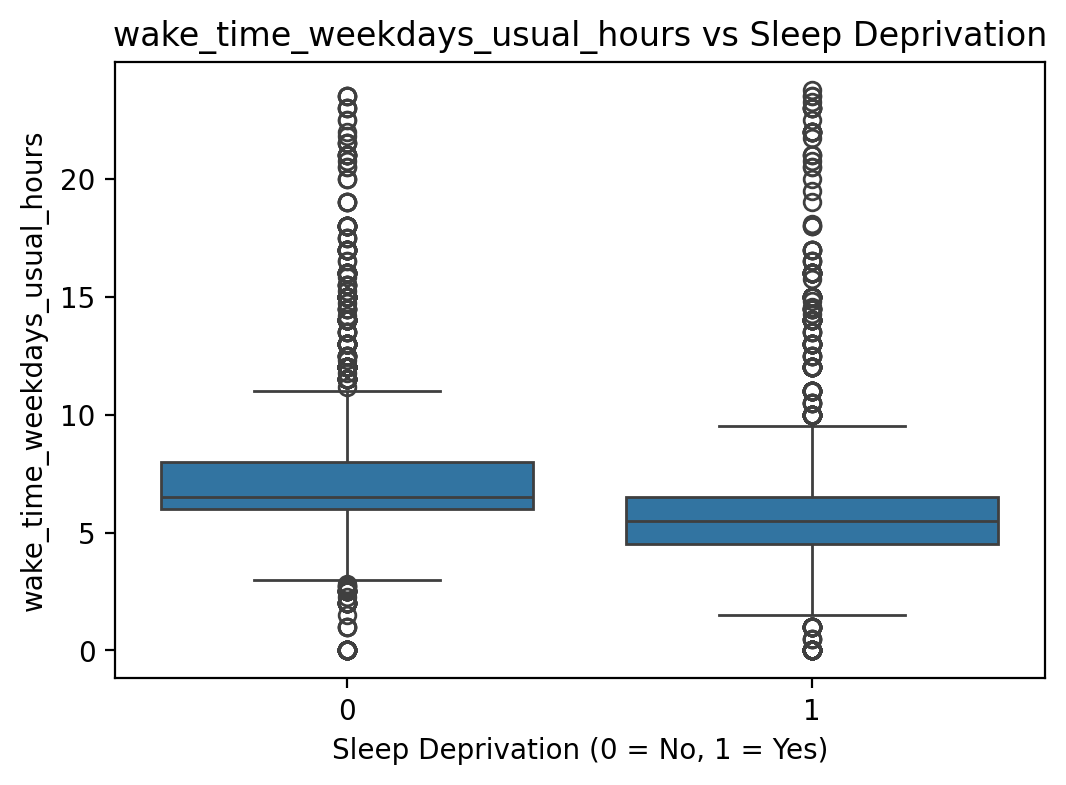

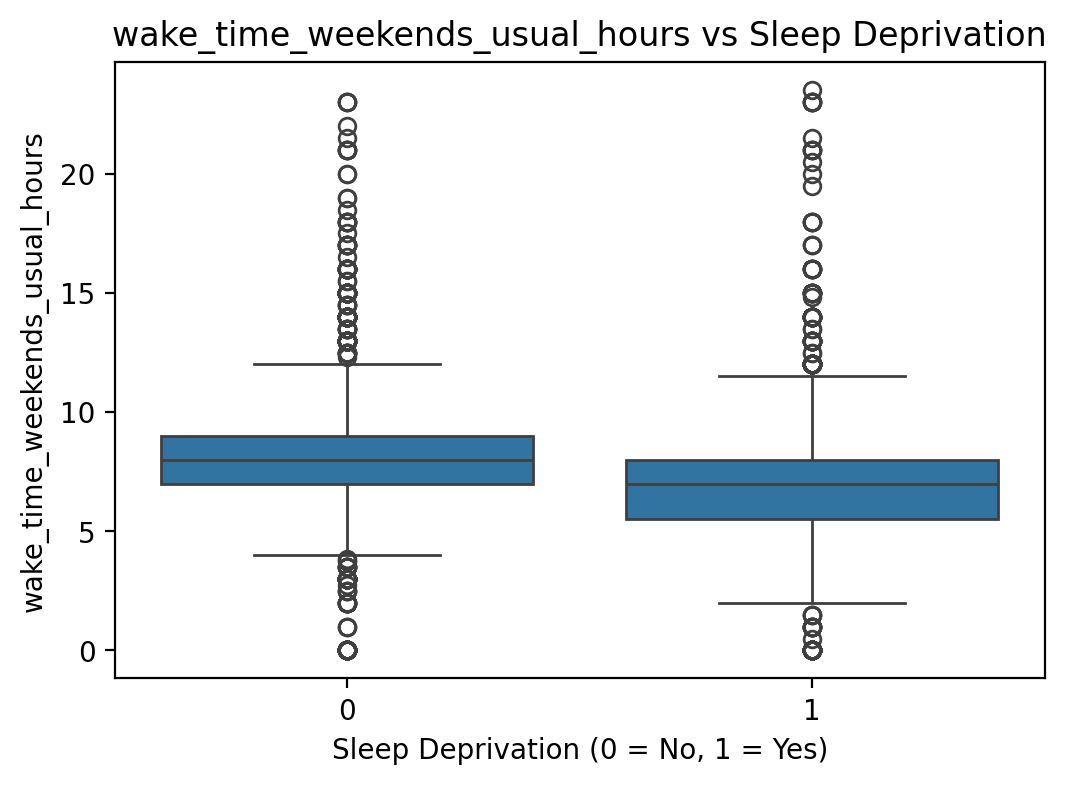

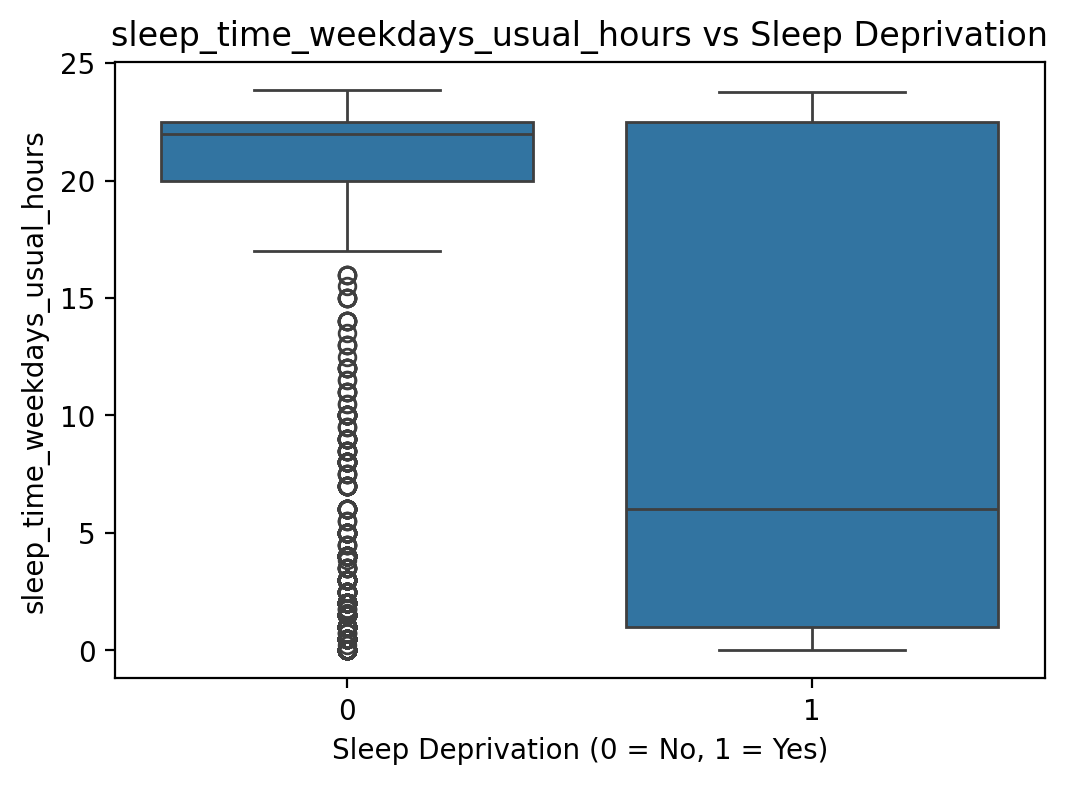

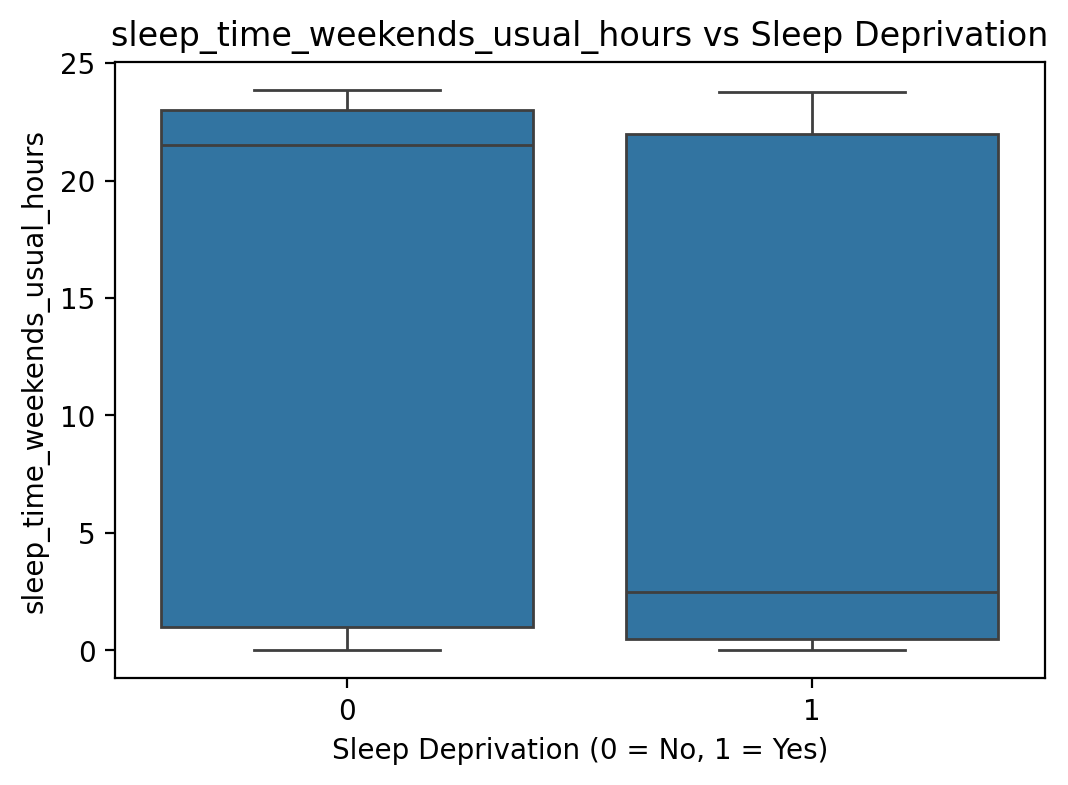

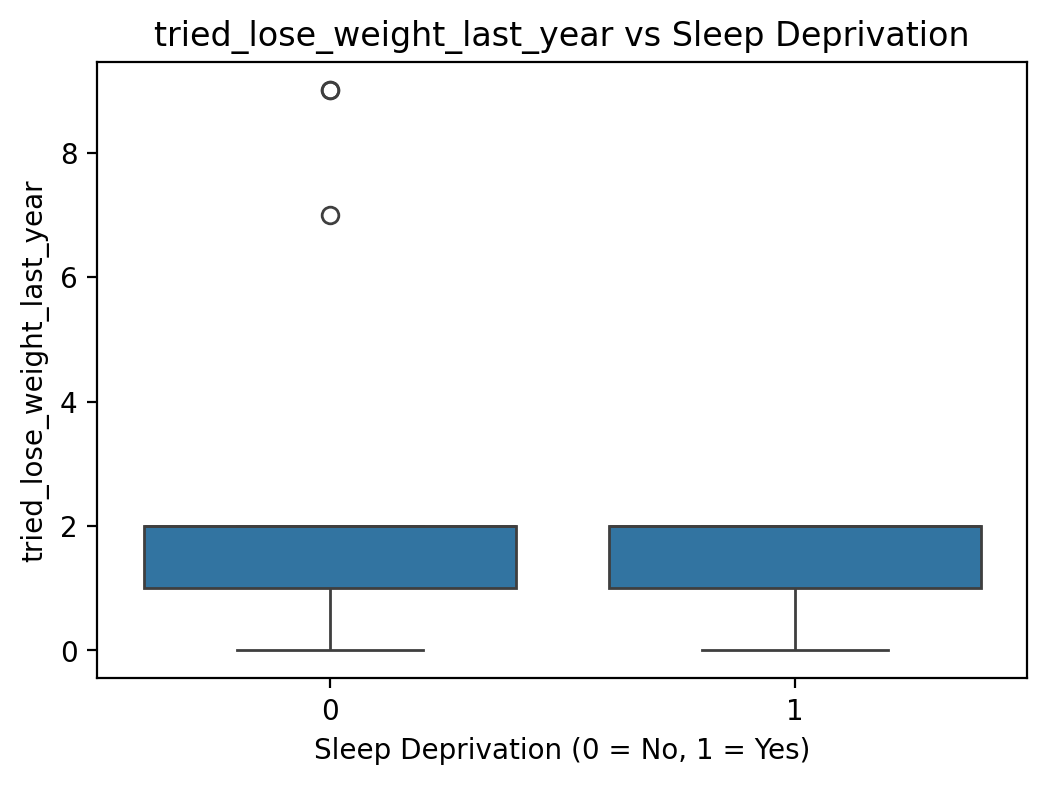

In [105]:
corr_target = merged_df['daily_sleep_duration']

# correlation with daily_sleep_duration
numeric_cols = X_final.select_dtypes(include=['float64', 'int64', 'Int64']).columns
if len(numeric_cols) > 0:
    corr = X_final[numeric_cols].join(corr_target).corr()['daily_sleep_duration'].sort_values(ascending=False)
else:
    print('no numeric columns for correlation check')

# boxplot for top 5 features (excluding target)
if len(numeric_cols) > 1:
    top_5 = corr.index[1:6]
    for col in top_5:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=y, y=X_final[col], data=X_final)
        plt.title(f'{col} vs Sleep Deprivation')
        plt.xlabel('Sleep Deprivation (0 = No, 1 = Yes)')
        plt.ylabel(col)
        plt.show()
else:
    print('not enough numeric columns for plot')

In [106]:
# encode string and category columns
X_encoded = X_final.copy()
le = LabelEncoder()

cat_cols = X_final.select_dtypes(include=['category', 'object']).columns
for col in cat_cols:
    if X_final[col].dtype.name == 'category':
        X_encoded[col] = X_encoded[col].cat.add_categories([-1]).fillna(-1).astype(str)
    else:
        X_encoded[col] = X_encoded[col].fillna('missing').astype(str)
    X_encoded[col] = le.fit_transform(X_encoded[col])

# convert missing type from pandas.NA to np.nan
X_encoded = X_encoded.replace({pd.NA: np.nan})

# fill missing values in numeric columns with mean
numeric_cols = X_encoded.select_dtypes(include=['float64', 'int64', 'Int64']).columns
X_encoded[numeric_cols] = X_encoded[numeric_cols].fillna(X_encoded[numeric_cols].mean())

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=777)
rf.fit(X_train, y_train)

# get top important features
feature_importance = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print(feature_importance)

# select top 10 features
selected_features = feature_importance['Feature'].head(10).tolist()
print(selected_features)

# make final dataset
final_df = X_final[selected_features].join(y)

final_df.head(2)

                                           Feature  Importance
1                   wake_time_weekdays_usual_hours    0.149247
0                  sleep_time_weekdays_usual_hours    0.123426
3                   wake_time_weekends_usual_hours    0.091165
2                  sleep_time_weekends_usual_hours    0.068022
4                           sleep_time_consistency    0.029137
..                                             ...         ...
35                   treated_pelvic_infection_ever    0.000750
24  job_difficulty_due_to_mouth_last_year_frequent    0.000718
11                                   cancer_breast    0.000709
51              used_smokeless_tobacco_last_5_days    0.000617
12                                 cancer_prostate    0.000564

[109 rows x 2 columns]
['wake_time_weekdays_usual_hours', 'sleep_time_weekdays_usual_hours', 'wake_time_weekends_usual_hours', 'sleep_time_weekends_usual_hours', 'sleep_time_consistency', 'bmi', 'weight_last_1_year_pounds', 'weight_kg', 'curre

,wake_time_weekdays_usual_hours,sleep_time_weekdays_usual_hours,wake_time_weekends_usual_hours,sleep_time_weekends_usual_hours,sleep_time_consistency,bmi,weight_last_1_year_pounds,weight_kg,current_weight_pounds,weight_change_pounds,sleep_deprivation
0,7.0,21.5,9.0,0.0,21.5,26.499328,200.0,86.18248,190.0,-10.0,0
1,6.0,21.0,6.0,21.0,0.0,31.566364,220.0,99.79024,220.0,0.0,0


## Exclude: Sleep related variables

In [107]:
# list of columns to remove
exclude_vars = [
    'sleep_hours_weekends', 'sleep_hours_weekdays', 'wake_time_weekdays_usual',
    'sleep_time_weekends_usual', 'sleep_time_weekdays_usual', 'wake_time_weekends_usual',
    'weekday_sleep_duration', 'weekend_sleep_duration', 'final_weekday_duration', 'final_weekend_duration',
    'daily_sleep_duration',
    'respondent_id','questionnaire_mode_flag', # also remove these
    'wake_time_weekdays_usual_hours', 'sleep_time_weekdays_usual_hours', 'wake_time_weekends_usual_hours', 'sleep_time_weekends_usual_hours', 'sleep_time_consistency'
]

# split data into X and y
if 'sleep_deprivation' not in merged_df.columns:
    raise ValueError("'sleep_deprivation' column not found in merged_df")

X = merged_df.drop(columns=['sleep_deprivation'] + [col for col in exclude_vars if col in merged_df.columns])
y = merged_df['sleep_deprivation']

# check missing rate only in X
missing_ratio = X.isnull().mean()

# keep only columns with less than 80% missing
threshold = 0.8
keep_cols = missing_ratio[missing_ratio < threshold].index
X_filtered = X[keep_cols]

# keep only number columns
numeric_cols = X_filtered.select_dtypes(include=[np.number]).columns
X_numeric = X_filtered[numeric_cols]

# fill missing values with 0
X_numeric_filled = X_numeric.fillna(0)

# remove columns with very low variance
selector = VarianceThreshold(threshold=0.01)
X_variance_filtered = selector.fit_transform(X_numeric_filled)
selected_features = X_numeric_filled.columns[selector.get_support()].tolist()

# combine filtered number columns and non-number columns
non_numeric_cols = X_filtered.select_dtypes(exclude=[np.number]).columns.tolist()
X_final = pd.concat([
    pd.DataFrame(X_variance_filtered, columns=selected_features, index=X_filtered.index),
    X_filtered[non_numeric_cols]
], axis=1)

print('\nFinal X shape:', X_final.shape)
print('Final columns:', X_final.columns.tolist())


Final X shape: (18438, 104)
Final columns: ['urinate_before_reaching_toilet', 'frequent_urinary_leakage', 'significant_daily_impact', 'any_urinary_incontinence', 'metal_objects_in_body', 'ever_told_arthritis', 'cancer_breast', 'cancer_prostate', 'cancer_skin_non_melanoma', 'chronic_condition_count', 'difficulty_from_problems_last_2_weeks', 'depression_binary', 'sleep_problems_flag', 'fatigue_flag', 'functional_impairment', 'significant_impairment', 'sleep_disturbance_score', 'poor_oral_health', 'mouth_ache_frequency_last_year_frequent', 'job_difficulty_due_to_mouth_last_year_frequent', 'used_weed_control_last_7_days', 'used_insect_control_last_7_days', 'insect_control_use', 'weed_control_use', 'any_pesticide_use', 'aspirin_recommended', 'aspirin_self_medication', 'current_aspirin_use', 'total_deliveries', 'age_last_period', 'treated_pelvic_infection_ever', 'age_first_period', 'ever_been_pregnant', 'both_ovaries_removed', 'had_hysterectomy', 'regular_periods_last_12_months', 'periods_s


correlation with sleep duration:
daily_sleep_duration              1.000000
tried_lose_weight_last_year       0.057130
regular_periods_last_12_months    0.046320
age_first_period                  0.039864
periods_started                   0.039317
weight_change_pounds              0.033510
cancer_breast                     0.025227
current_aspirin_use               0.005853
cancer_prostate                   0.005437
both_ovaries_removed              0.004568
Name: daily_sleep_duration, dtype: float64
sleep_problems_flag         -0.075426
sleep_disturbance_score     -0.082738
weight_kg                   -0.101693
current_weight_pounds       -0.101693
weight_last_1_year_pounds   -0.115478
Name: daily_sleep_duration, dtype: float64


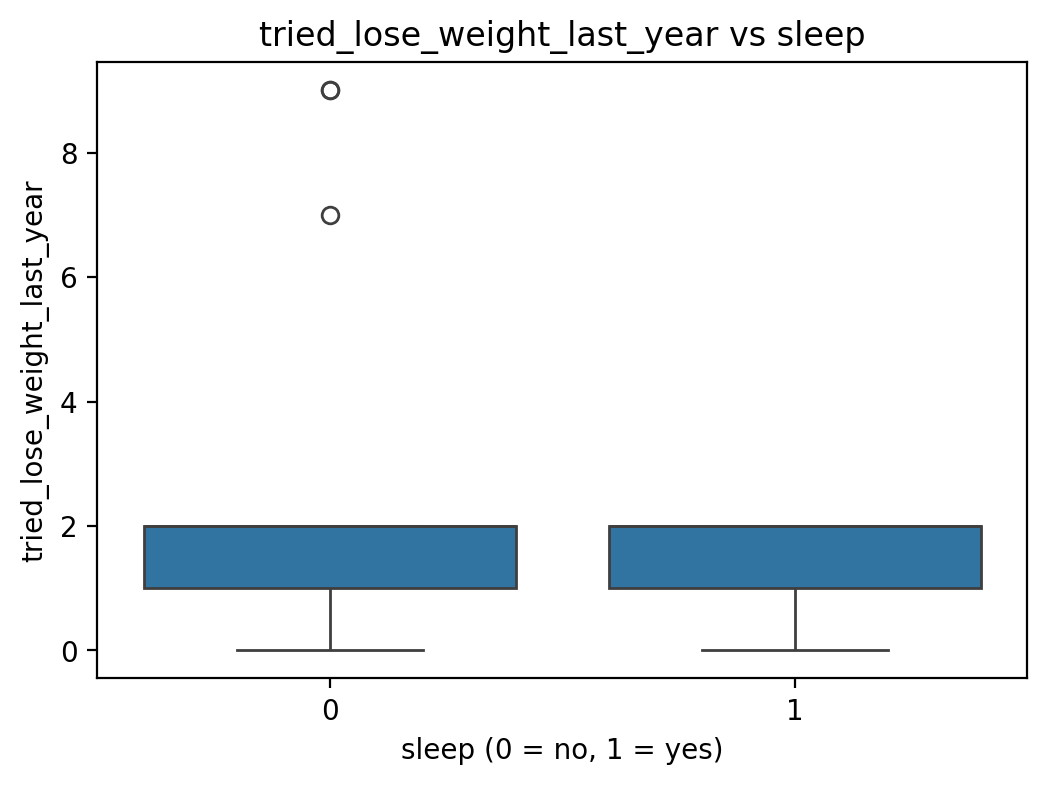

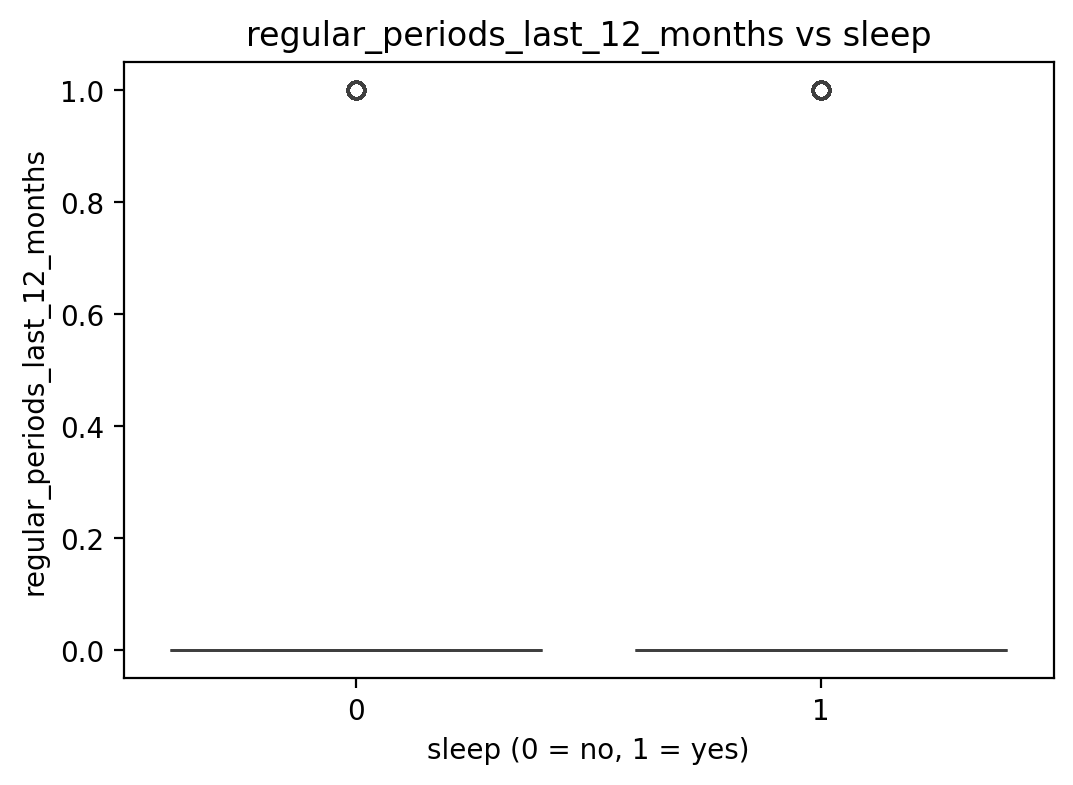

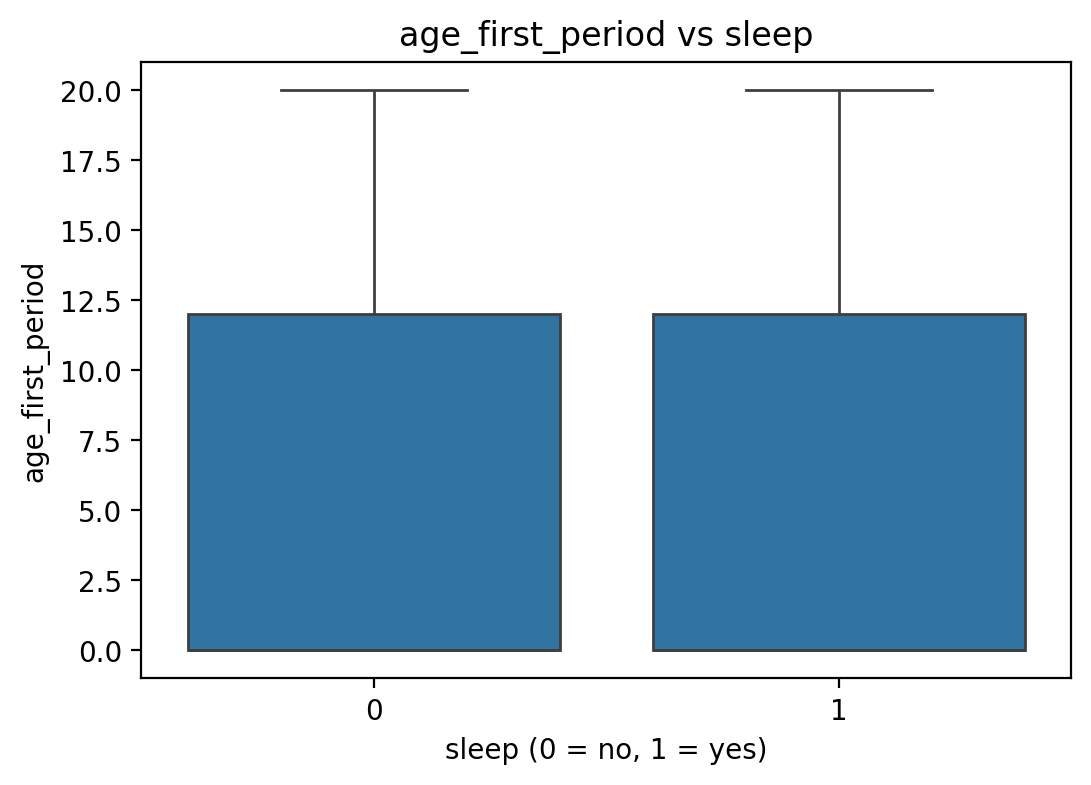

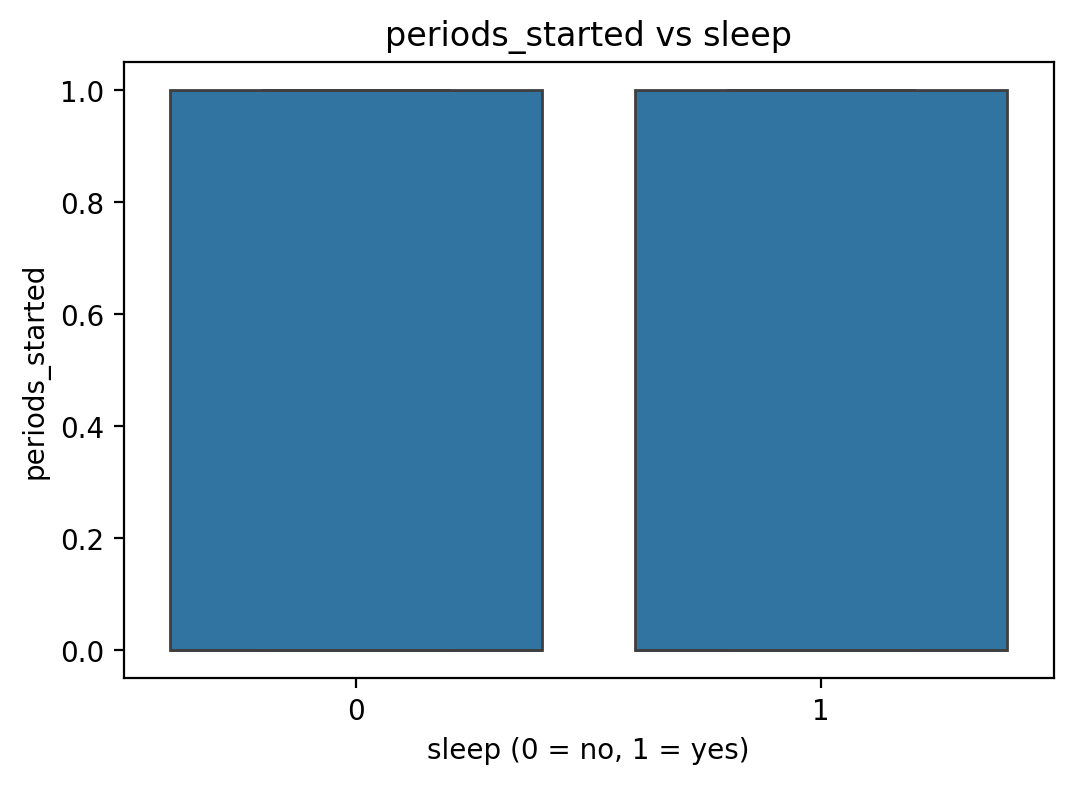

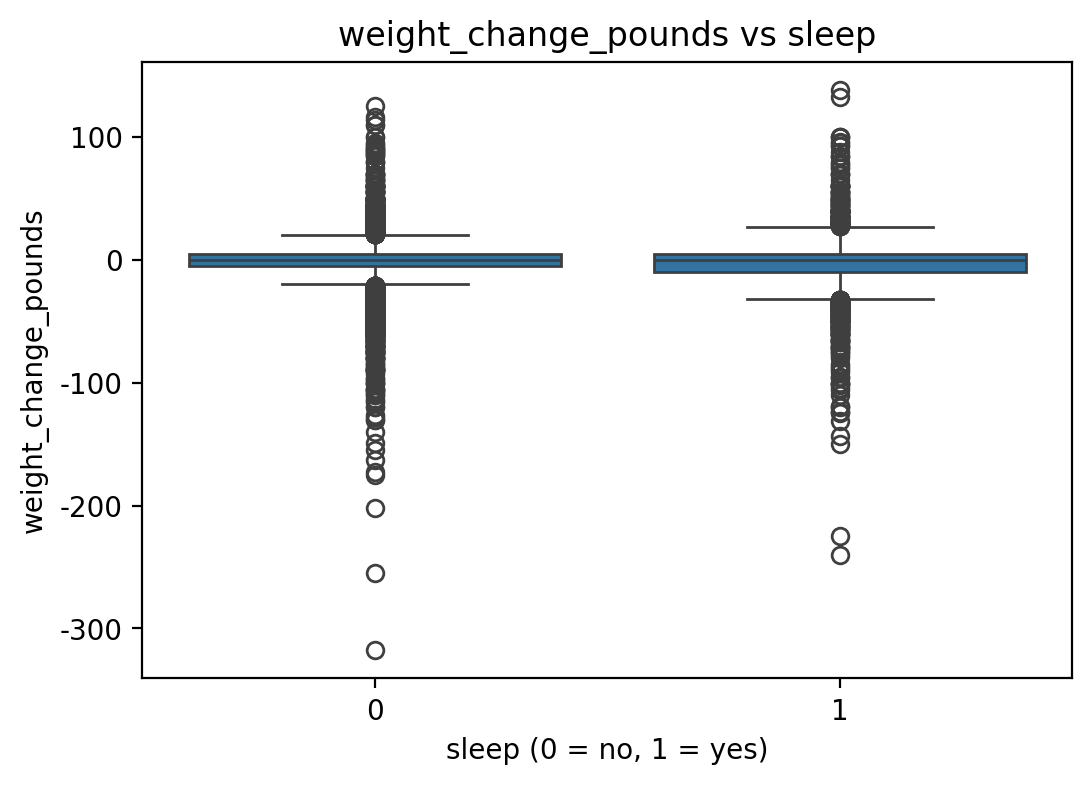

In [108]:
corr_target = merged_df['daily_sleep_duration']

# check correlation between sleep and other number columns
numeric_cols = X_final.select_dtypes(include=['float64', 'int64', 'Int64']).columns
if len(numeric_cols) > 0:
    corr = X_final[numeric_cols].join(corr_target).corr()['daily_sleep_duration'].sort_values(ascending=False)
    print('\ncorrelation with sleep duration:')
    print(corr.head(10)) # top 10
    print(corr.tail(5)) # bottom 5
else:
    print('\nno numeric columns for correlation')

# draw boxplot for top 5 related columns (except sleep column)
if len(numeric_cols) > 1:
    top_5 = corr.index[1:6] # skip first (target), take next 5
    for col in top_5:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=y, y=X_final[col], data=X_final)
        plt.title(f'{col} vs sleep')
        plt.xlabel('sleep (0 = no, 1 = yes)')
        plt.ylabel(col)
        plt.show()
else:
    print('\nnot enough columns to show boxplot')

In [109]:
# encode string and category columns
X_encoded = X_final.copy()
le = LabelEncoder()

cat_cols = X_final.select_dtypes(include=['category', 'object']).columns
for col in cat_cols:
    print(f'\nunique values in {col} before:', X_final[col].unique())
    if X_final[col].dtype.name == 'category':
        X_encoded[col] = X_encoded[col].cat.add_categories([-1]).fillna(-1).astype(str)
    else:
        X_encoded[col] = X_encoded[col].fillna('missing').astype(str)
    X_encoded[col] = le.fit_transform(X_encoded[col])
    print(f'unique values in {col} after:', X_encoded[col].unique())

# replace missing values
print('\nmissing values before:', X_encoded.isnull().sum().sum())
X_encoded = X_encoded.replace({pd.NA: np.nan})
print('missing values after:', X_encoded.isnull().sum().sum())

# fill missing numbers with mean
numeric_cols = X_encoded.select_dtypes(include=['float64', 'int64', 'Int64']).columns
X_encoded[numeric_cols] = X_encoded[numeric_cols].fillna(X_encoded[numeric_cols].mean())

print('X_encoded shape:', X_encoded.shape)
print('missing after fill:', X_encoded.isnull().sum().sum())


unique values in daily_activities_affected before: [nan 2.0 1.0 5.0 3.0 4.0 <NA>]
unique values in daily_activities_affected after: [5 1 0 4 2 3]

unique values in urine_loss_amount before: [nan 2.0 1.0 3.0 <NA>]
unique values in urine_loss_amount after: [3 1 0 2]

unique values in urinary_leakage_frequency before: [nan 2.0 1.0 4.0 3.0 5.0 <NA>]
unique values in urinary_leakage_frequency after: [5 1 0 3 2 4]

unique values in urinary_leakage_freq_category before: [NaN, '<1/month', 'never', 'few/week', 'few/month', 'daily']
Categories (5, object): ['<1/month', 'daily', 'few/month', 'few/week', 'never']
unique values in urinary_leakage_freq_category after: [0 1 5 4 3 2]

unique values in urine_loss_category before: [NaN, 'small_splashes', 'drops', 'more']
Categories (3, object): ['drops', 'more', 'small_splashes']
unique values in urine_loss_category after: [0 3 1 2]

unique values in daily_impact_category before: [NaN, 'only_a_little', 'not_at_all', 'greatly', 'somewhat', 'very_much']


In [110]:
X_encoded.dtypes

urinate_before_reaching_toilet    float64
frequent_urinary_leakage          float64
significant_daily_impact          float64
any_urinary_incontinence          float64
metal_objects_in_body             float64
                                   ...   
smokers_inside_category             int64
secondhand_smoke_exposure           int64
tobacco_use_type                    int64
bmi_category                        int64
weight_change_category              int64
Length: 104, dtype: object

In [111]:
# split train and test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

# train model
rf = RandomForestClassifier(n_estimators=100, random_state=777)
rf.fit(X_train, y_train)

# check feature importance
feature_importance = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print(feature_importance.head(10))

# top 10 features
selected_features = feature_importance['Feature'].head(10).tolist()
print('\nselected features:', selected_features)

# final dataframe
final_df = X_final[selected_features].join(y)
print('\nfinal_df shape:', final_df.shape)
print('final_df columns:', final_df.columns.tolist())

final_df.head(2)

X_train shape: (14750, 104)
X_test shape: (3688, 104)
                       Feature  Importance
57                         bmi    0.049496
52   weight_last_1_year_pounds    0.043761
51       current_weight_pounds    0.041576
56                   weight_kg    0.040987
58        weight_change_pounds    0.037541
50       current_height_inches    0.032709
55               height_meters    0.032454
88  minutes_sedentary_activity    0.030544
89     sedentary_hours_per_day    0.029991
77      hours_worked_last_week    0.024739

selected features: ['bmi', 'weight_last_1_year_pounds', 'current_weight_pounds', 'weight_kg', 'weight_change_pounds', 'current_height_inches', 'height_meters', 'minutes_sedentary_activity', 'sedentary_hours_per_day', 'hours_worked_last_week']

final_df shape: (18438, 11)
final_df columns: ['bmi', 'weight_last_1_year_pounds', 'current_weight_pounds', 'weight_kg', 'weight_change_pounds', 'current_height_inches', 'height_meters', 'minutes_sedentary_activity', 'sedentary_

,bmi,weight_last_1_year_pounds,current_weight_pounds,weight_kg,weight_change_pounds,current_height_inches,height_meters,minutes_sedentary_activity,sedentary_hours_per_day,hours_worked_last_week,sleep_deprivation
0,26.499328,200.0,190.0,86.18248,-10.0,71.0,1.8034,360.0,6.0,40.0,0
1,31.566364,220.0,220.0,99.79024,0.0,70.0,1.7780,480.0,8.0,32.0,0
